In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer, CTGANSynthesizer

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.resource_utils import split_datasets_path, models_and_scalers_path
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *

/home/mileva/mambaforge/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mileva/mambaforge/envs/torch/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mileva/Documents/Lyle/biked-commons/src/biked_commons/bike_embedding/../../biked_commons/prediction/usability_predictors.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct maliciou

In [ ]:
data = pd.read_csv(split_datasets_path("bike_bench_mixed_modality.csv"), index_col=0)

In [3]:
import sdv
from sdv.metadata import Metadata  
metadata = Metadata.detect_from_dataframe(
    data=data,
    table_name='my_table'
)
from biked_commons.transformation.one_hot_encoding import ONE_HOT_ENCODED_CLIPS_COLUMNS, BOOLEAN_COLUMNS
categorical_cols = ONE_HOT_ENCODED_CLIPS_COLUMNS
boolean_cols = BOOLEAN_COLUMNS
continuous_cols = data.columns.difference(categorical_cols + boolean_cols).tolist()

# # ensure categoricals are flagged
# for col in categorical_cols:
#     metadata.update_column(col, sdtype='categorical')
# metadata.validate()

In [4]:
data[continuous_cols] = data[continuous_cols].astype(np.float32)

In [5]:
# add eps to all continuous columns

for col in data.columns:
    if col not in categorical_cols and col not in boolean_cols:
        data[col] = data[col] + np.ones_like(data[col])
        #make float
        data[col] = data[col].astype(float)

In [ ]:




# synthesizer = GaussianCopulaSynthesizer(metadata, enforce_rounding = False, enforce_min_max_values=False)
synthesizer = CTGANSynthesizer(metadata, verbose=True, epochs=500)

# synthesizer = GaussianCopulaSynthesizer(metadata, enforce_rounding = False, enforce_min_max_values=False, default_distribution='gaussian_kde')
synthesizer.fit(data)

Gen. (-2.73) | Discrim. (-0.55): 100%|██████████| 500/500 [03:24<00:00,  2.45it/s]


In [ ]:
save_path = models_and_scalers_path("CTGAN.pkl")

In [ ]:
synthesizer.save(save_path)

In [14]:
synthesizer = CTGANSynthesizer.load(filepath=save_path)

In [15]:
synthetic_collapsed = synthesizer.sample(num_rows=10000)

In [16]:
synthetic_collapsed

,CS textfield,BB textfield,Stack,Head angle,Head tube length textfield,Seat stay junction0,Seat tube length,Seat angle,DT Length,FORK0R,...,RIM_STYLE rear,SPOKES composite front,SPOKES composite rear,SBLADEW front,SBLADEW rear,Saddle length,Saddle height,Down tube diameter,Seatpost LENGTH,Seat tube type
0,387.86868,67.139141,702.427113,76.772020,118.498181,40.76,605.07,73.589453,614.949524,44.11,...,DISC,1,1,80.3,80.1,276.4,658.5,34.965629,296.0,0
1,387.44205,13.988073,462.541448,73.584112,154.757659,-5.33,363.48,65.097728,0.000000,44.77,...,SPOKED,1,1,79.8,79.9,275.3,738.3,35.223174,302.0,1
2,352.19446,74.881103,591.839087,79.160227,148.170990,46.36,612.36,77.064157,678.659230,44.76,...,SPOKED,1,1,79.9,80.1,262.8,812.7,35.115756,298.0,0
3,395.17996,43.859632,573.518707,72.943038,236.849988,182.44,400.22,80.797103,655.007527,44.11,...,SPOKED,1,1,79.7,79.7,289.8,727.7,34.766799,216.0,1
4,418.11679,73.365800,612.756228,71.864194,219.707919,44.67,465.64,74.180075,668.054997,30.93,...,SPOKED,1,1,79.7,79.6,300.0,731.9,34.748331,337.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,332.93582,3.868261,611.556747,71.512249,164.304941,-11.74,502.56,73.374472,638.812929,45.15,...,SPOKED,1,1,79.5,79.7,219.8,1033.4,42.924324,302.0,1
9996,339.26032,72.974796,633.806446,79.027713,132.674772,48.69,622.86,81.390039,682.304378,79.47,...,SPOKED,1,1,80.2,79.7,301.3,813.6,34.637998,335.0,1
9997,393.33608,72.858908,603.435489,76.301934,235.291591,41.66,516.07,74.807785,623.411005,58.32,...,SPOKED,1,1,80.0,80.0,274.3,668.7,43.128231,297.0,2
9998,395.95615,71.743670,618.715411,73.285898,239.132685,43.64,510.33,75.286721,630.409084,45.74,...,DISC,1,1,79.8,79.7,280.0,702.1,34.649140,298.0,1


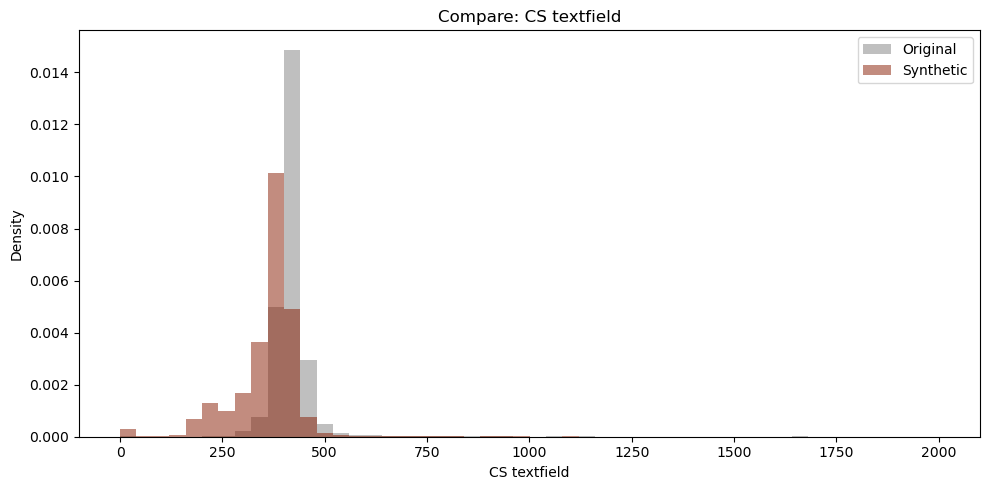

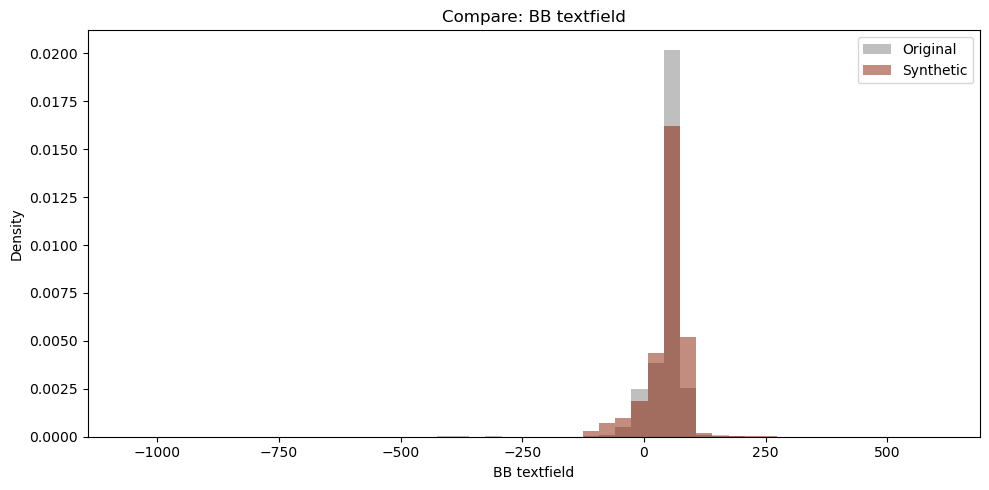

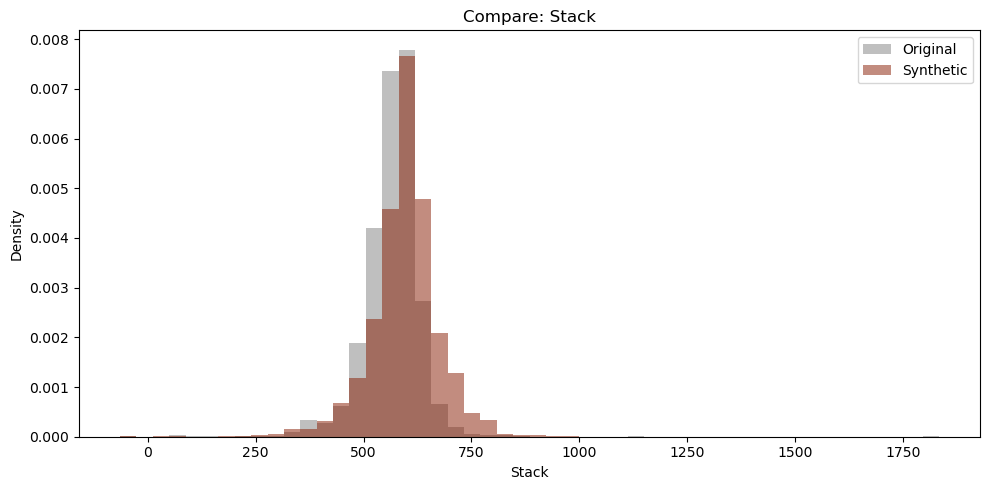

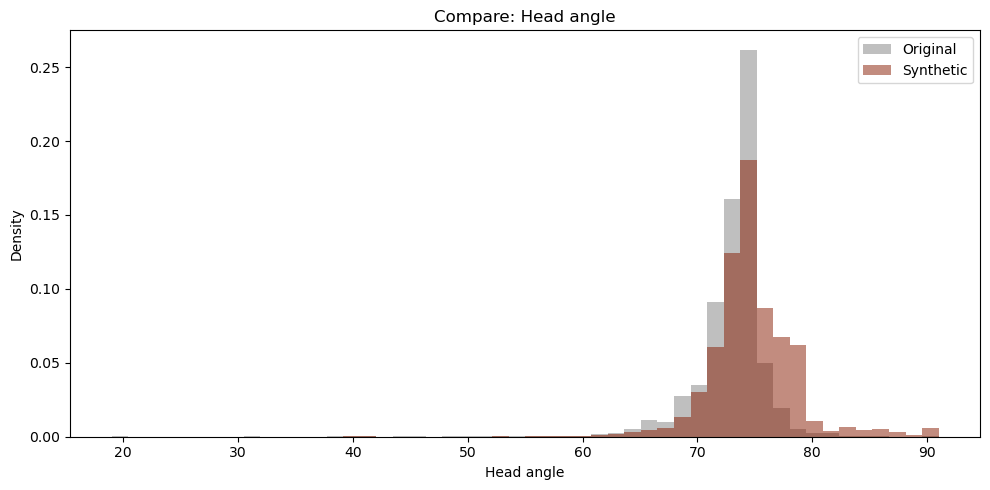

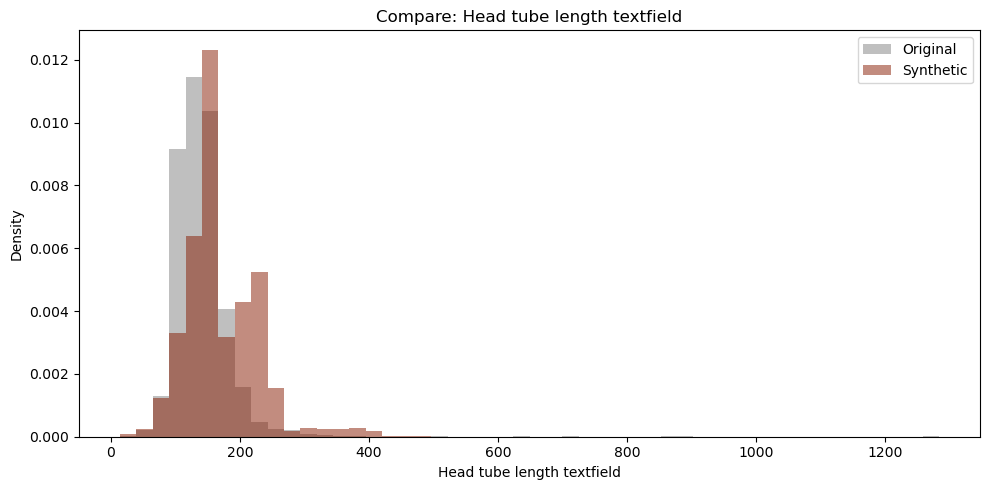

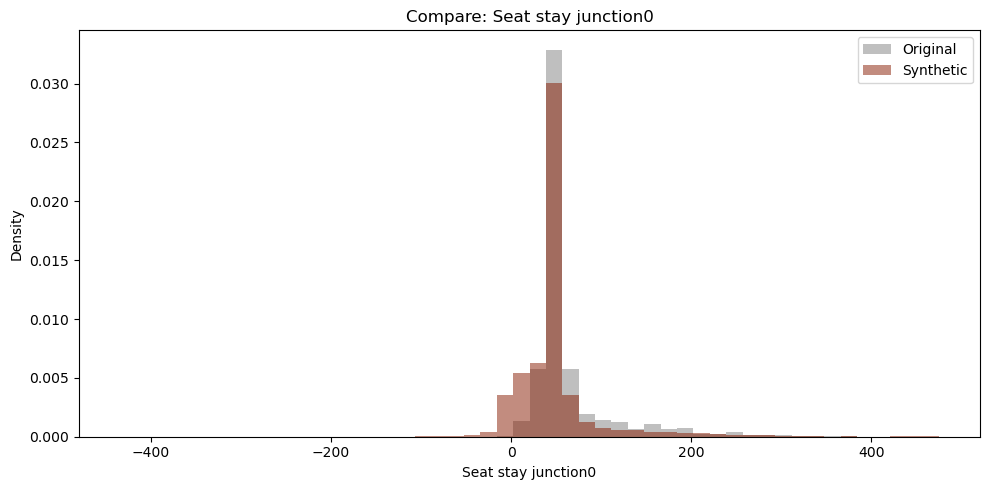

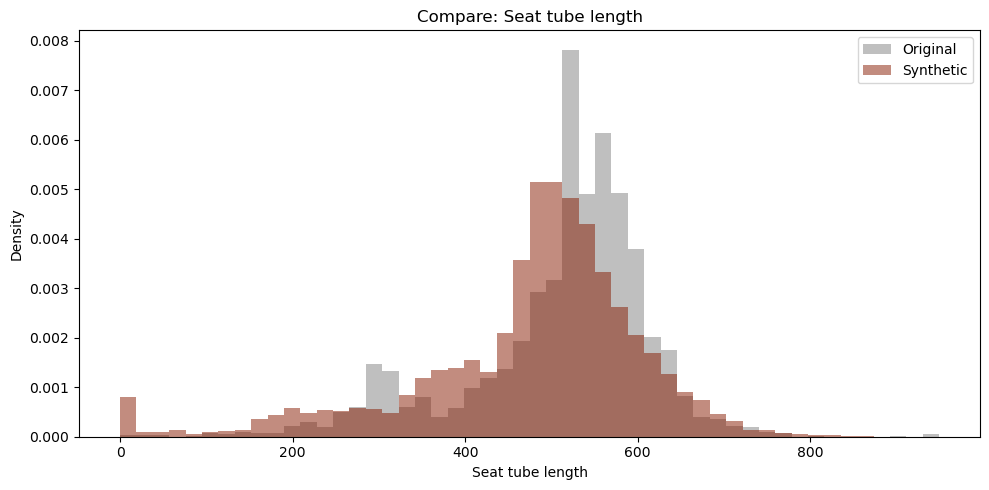

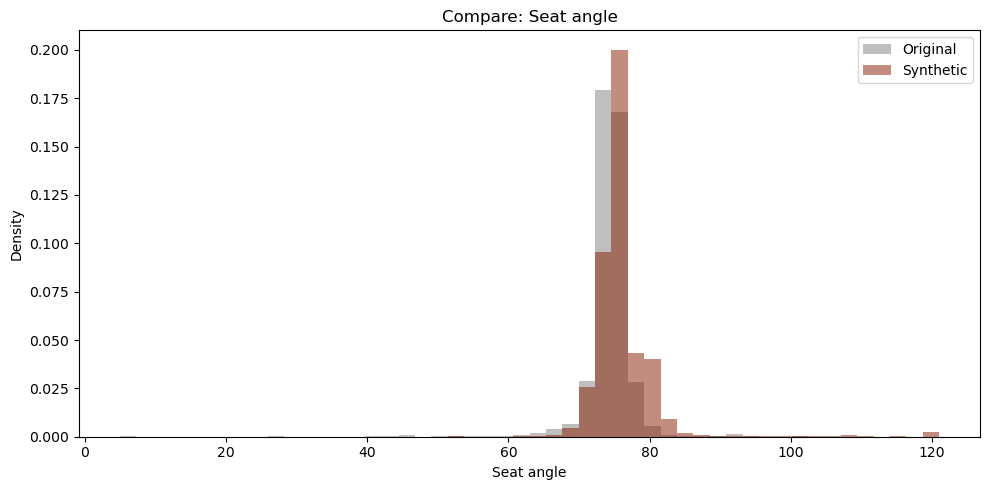

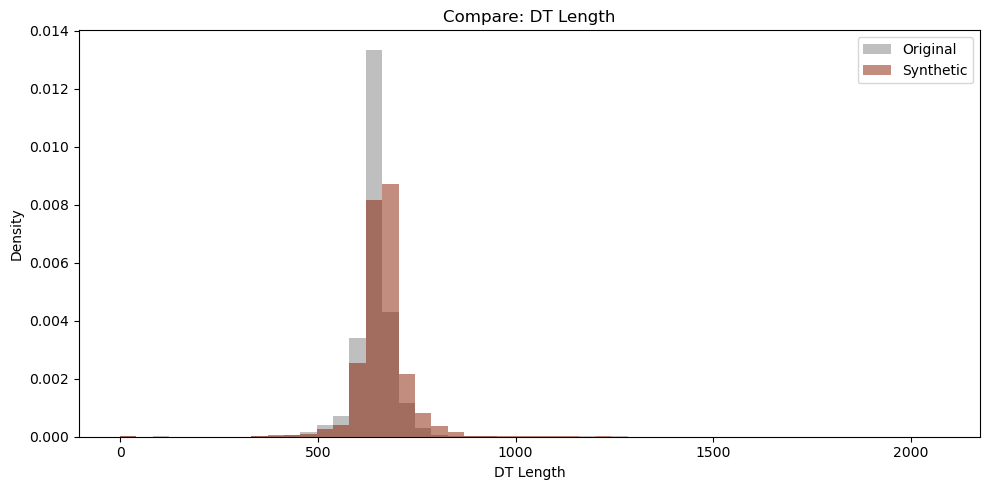

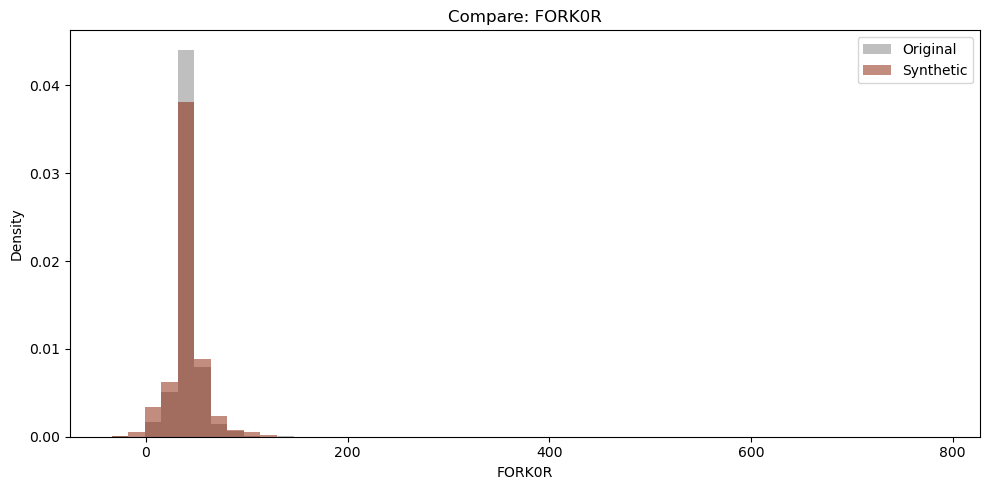

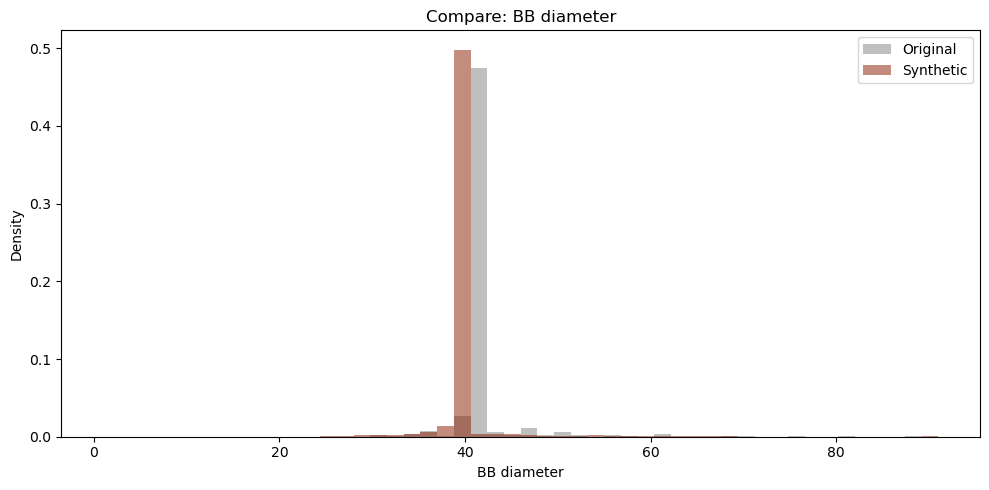

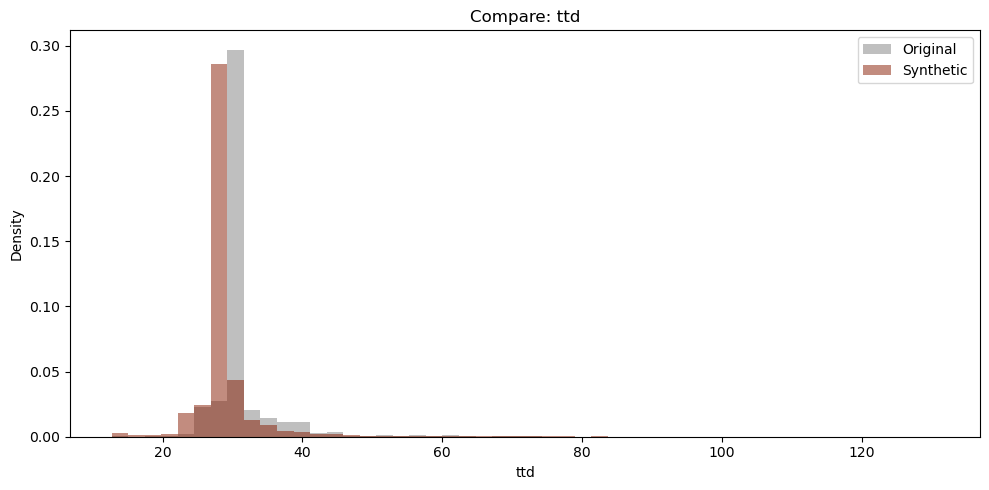

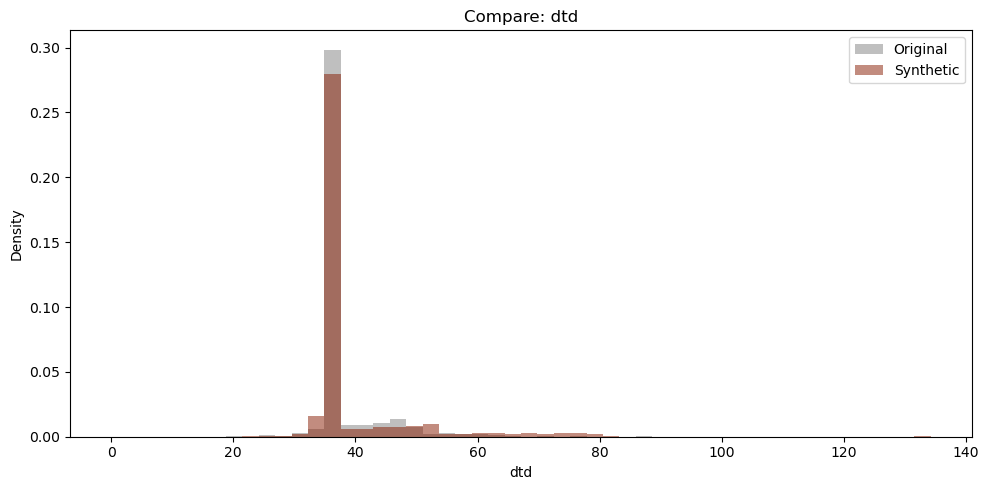

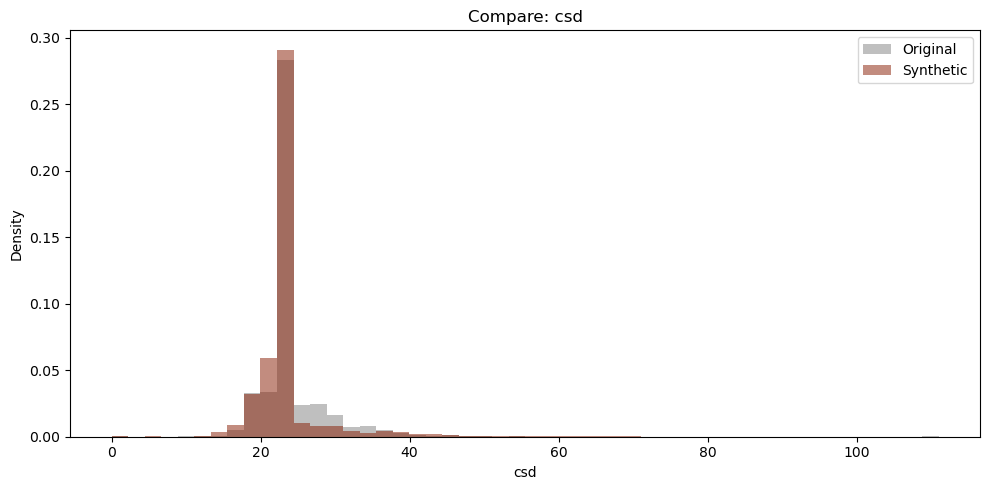

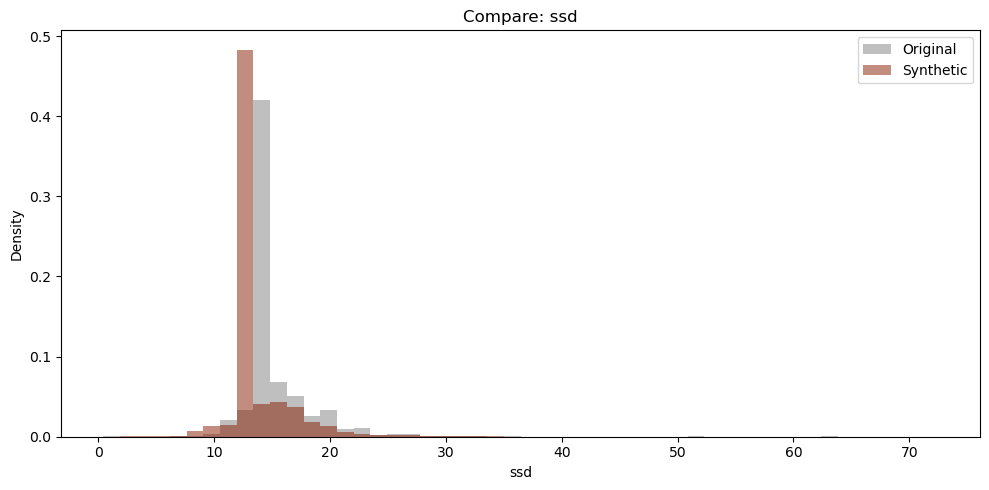

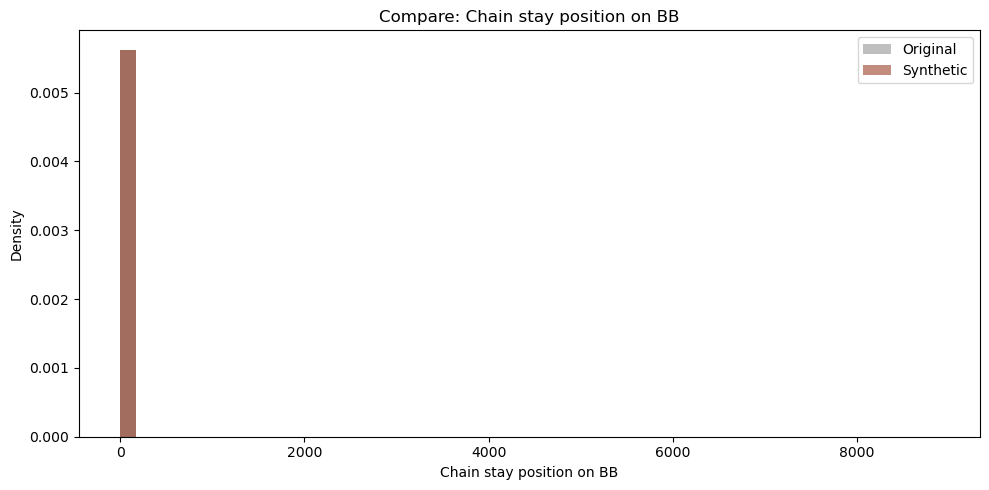

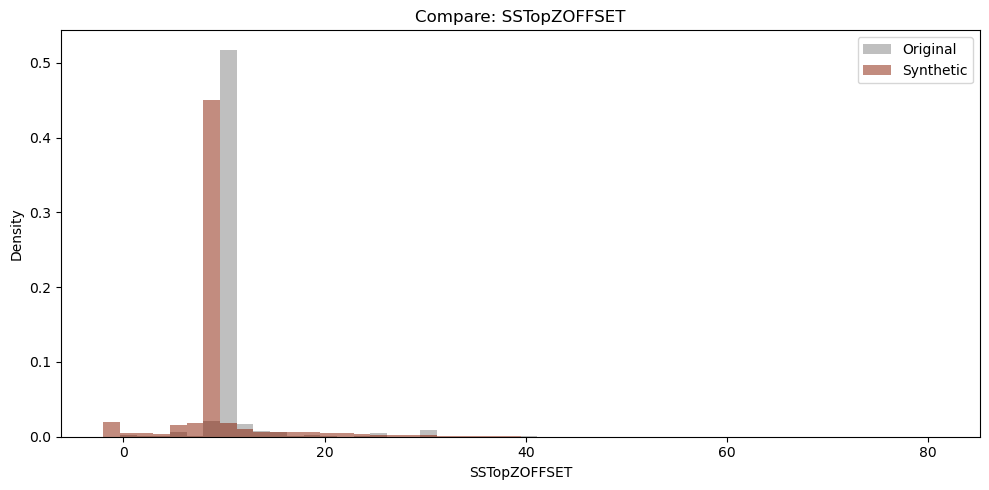

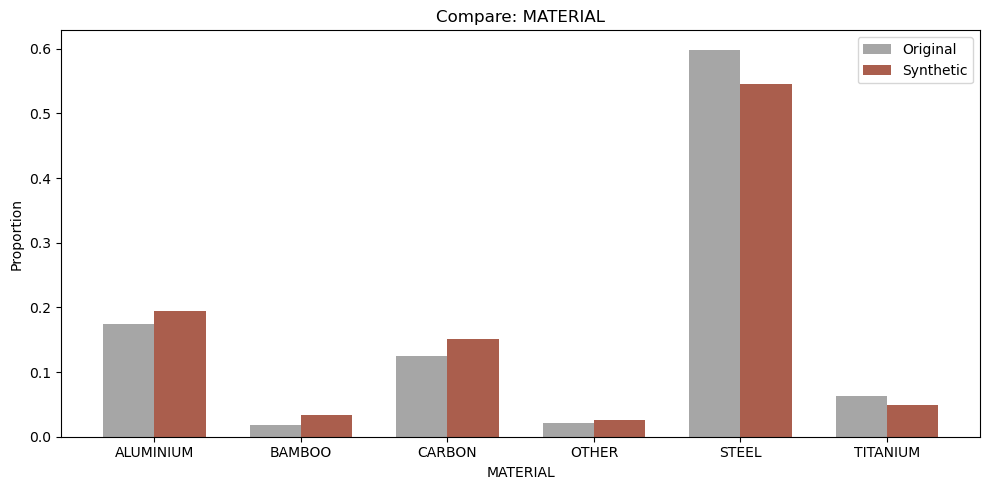

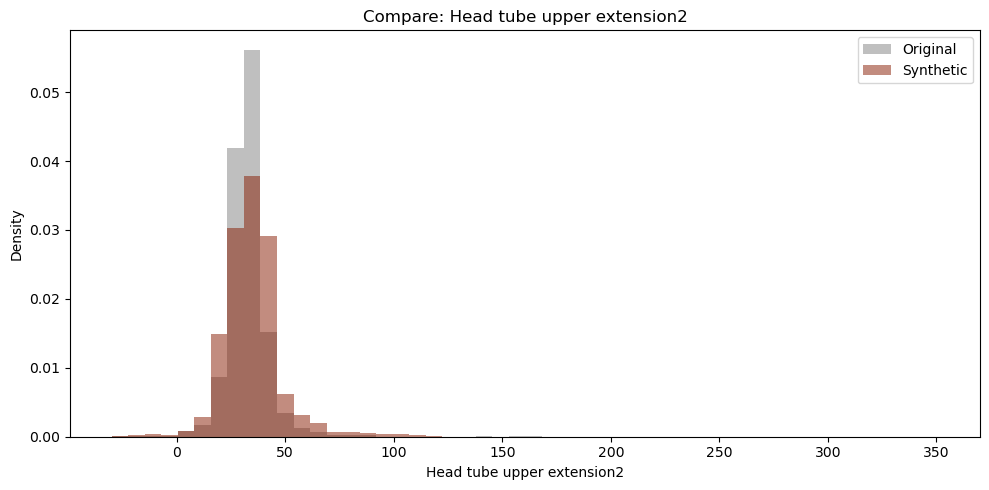

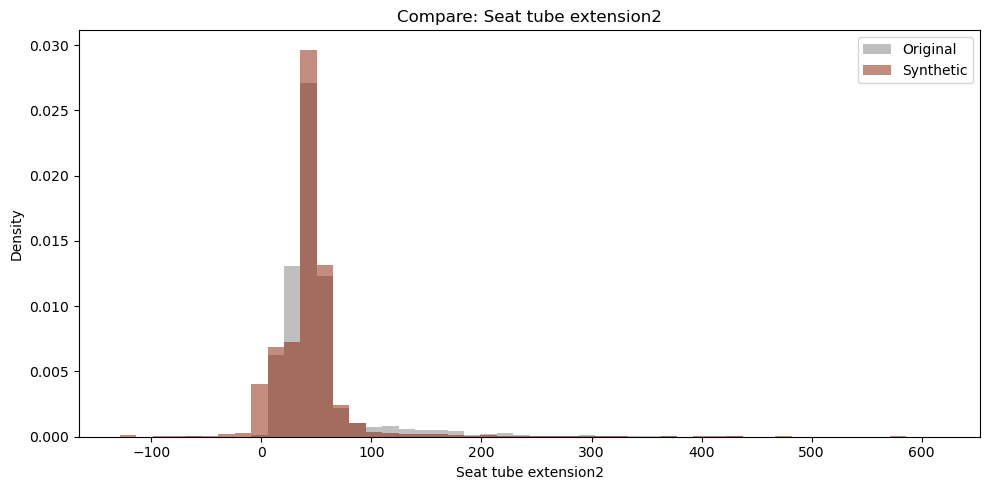

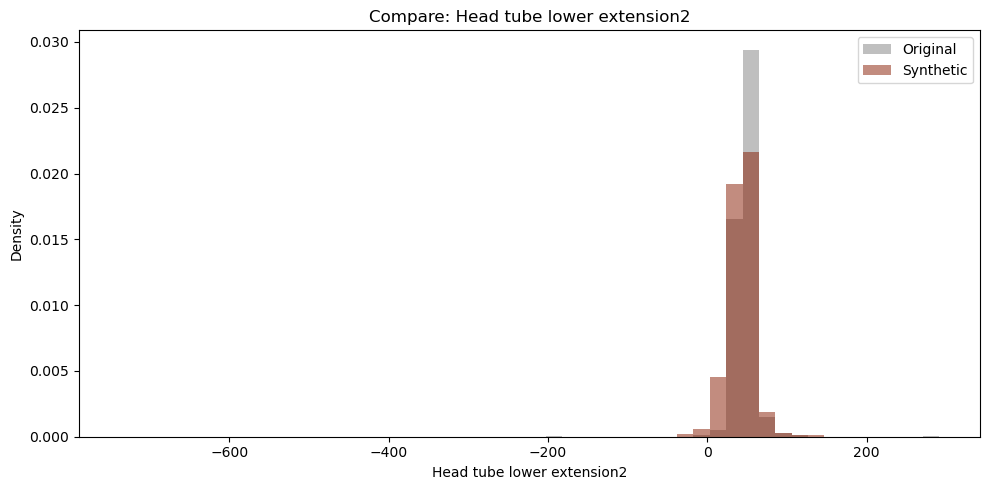

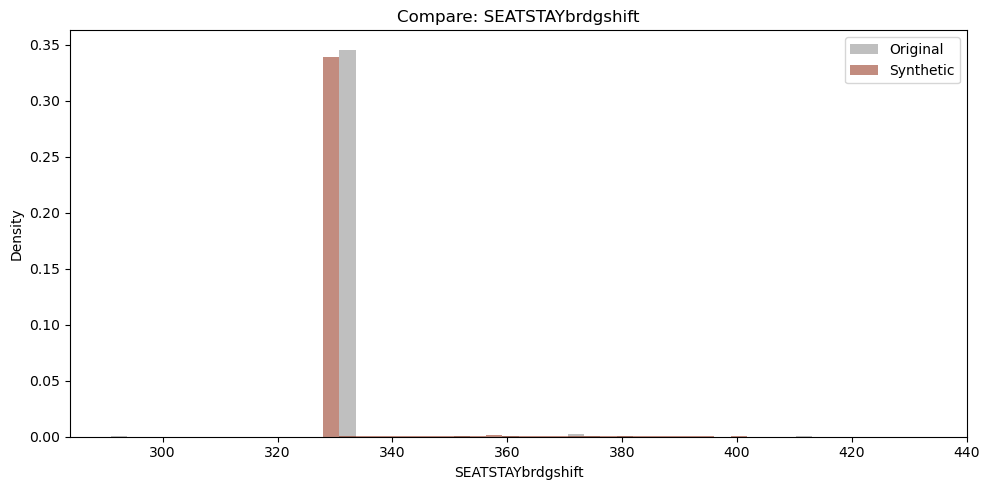

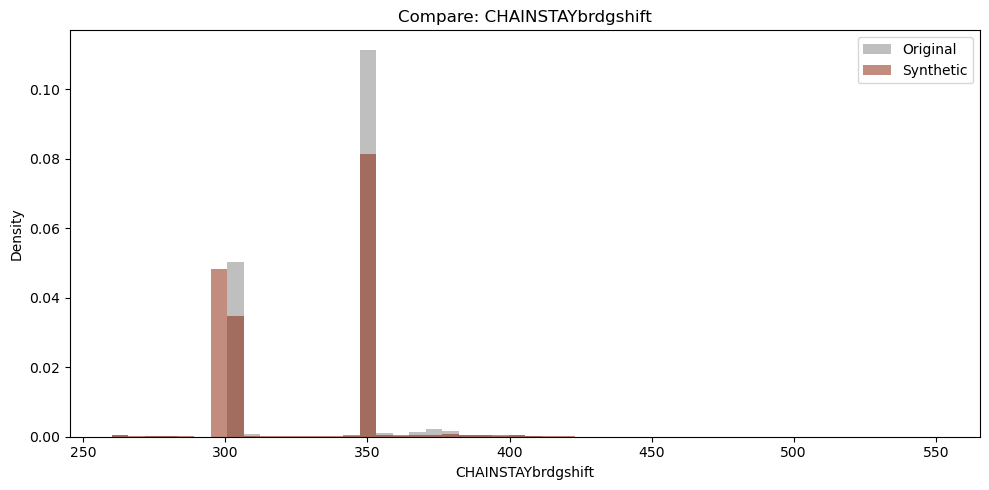

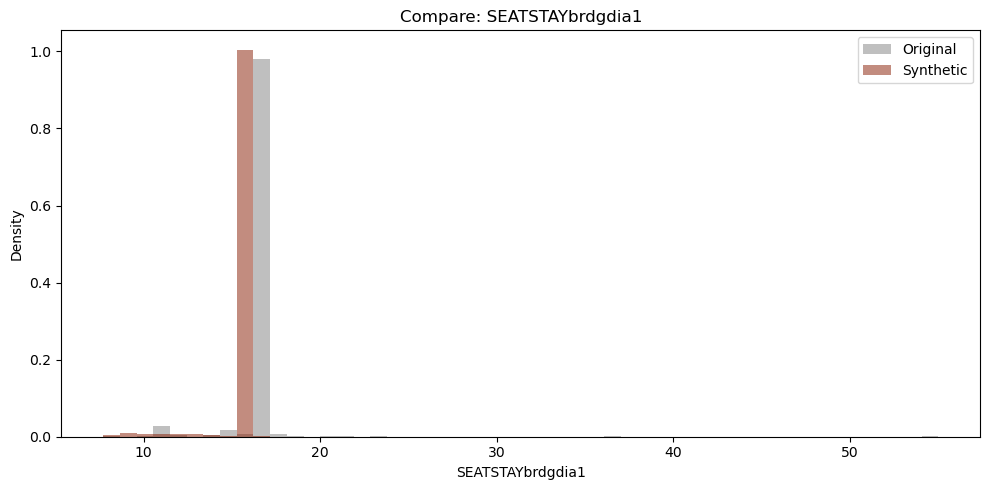

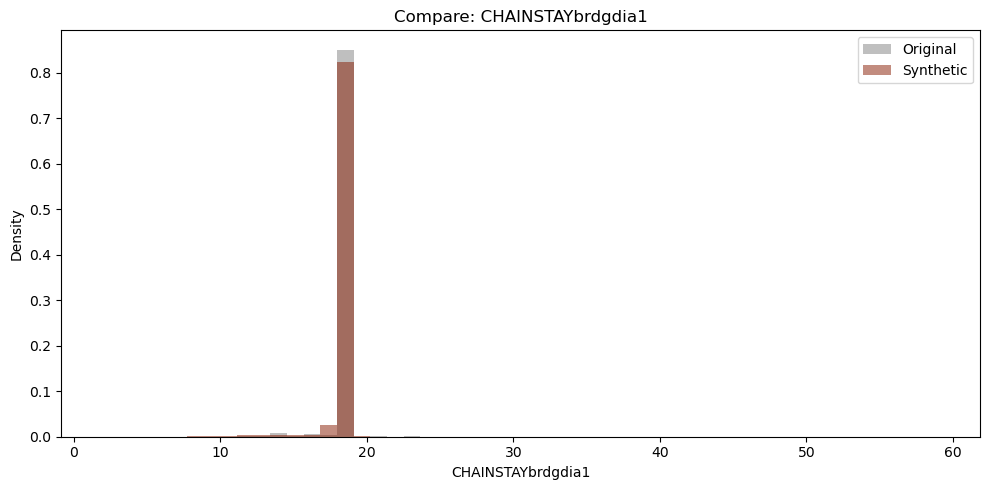

/home/mileva/mambaforge/envs/torch/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


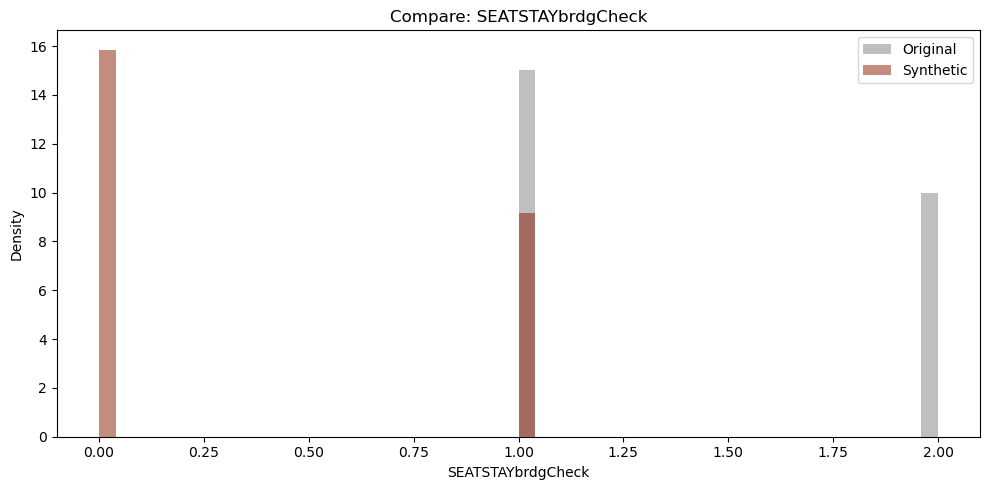

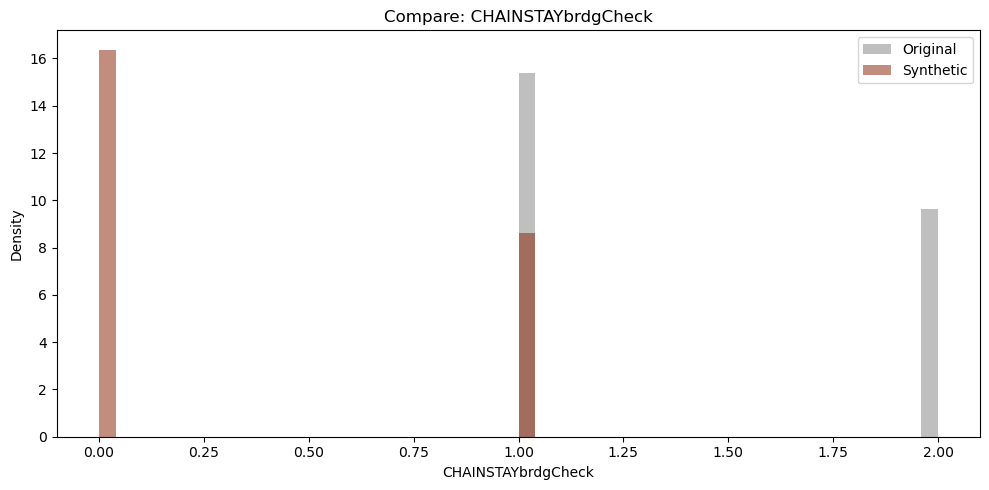

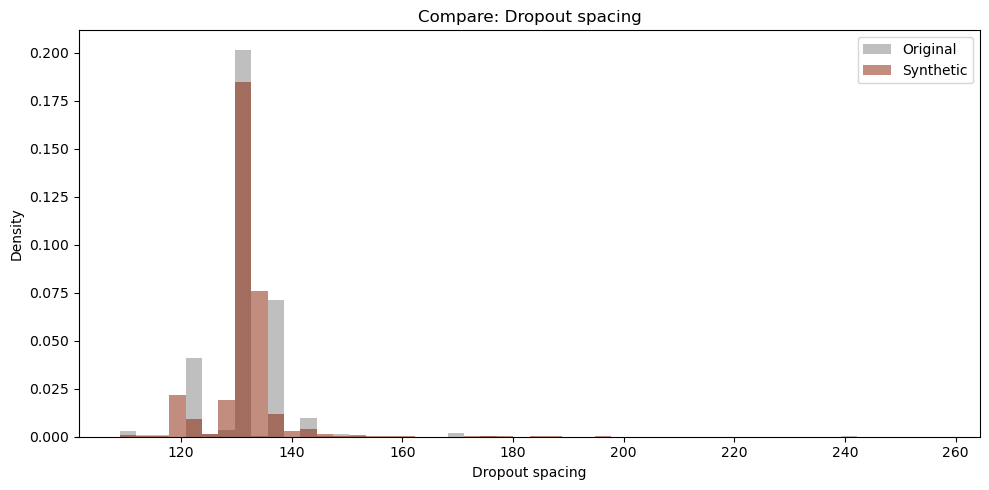

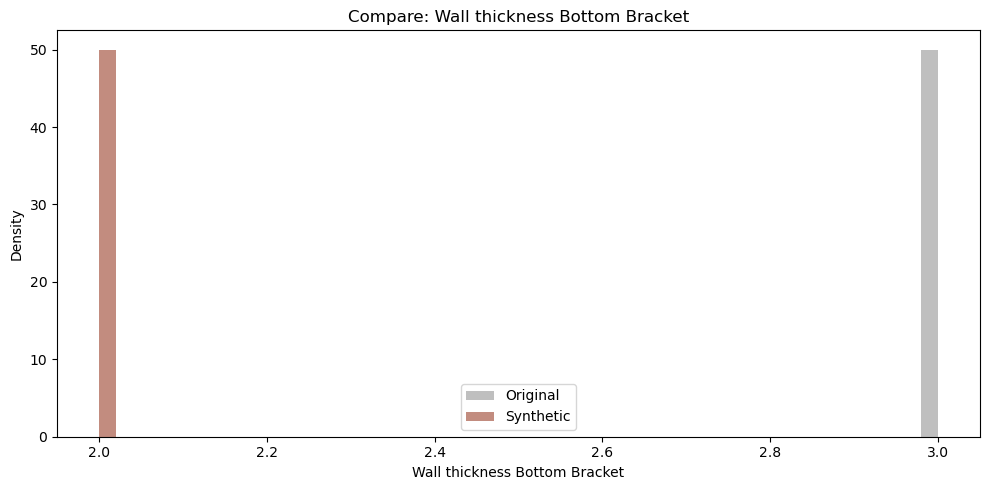

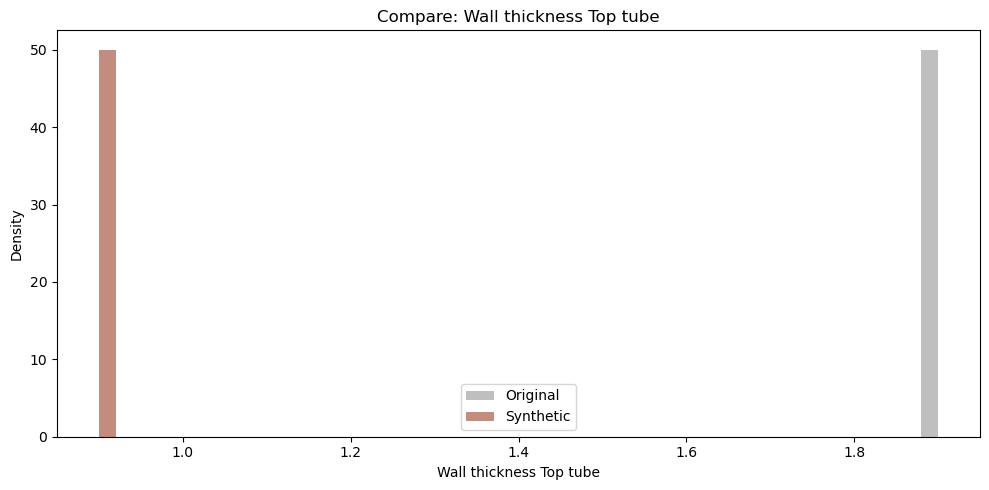

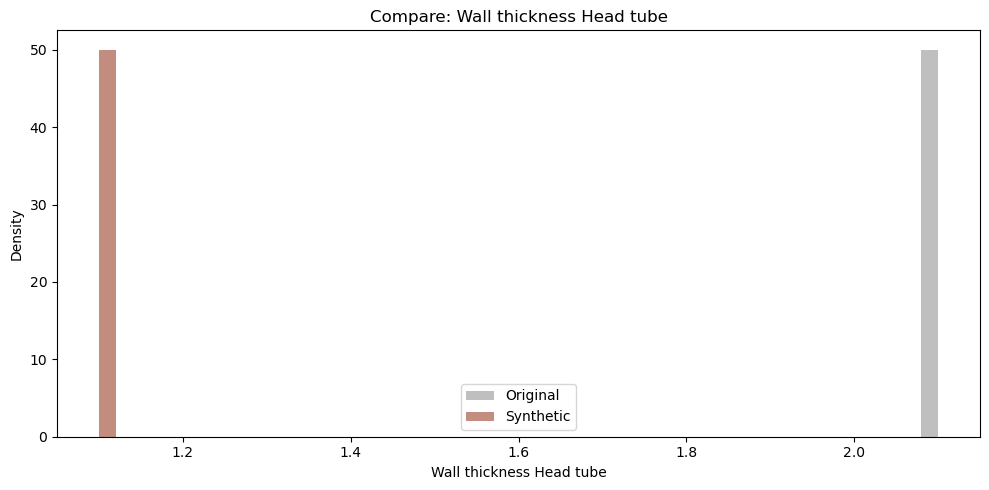

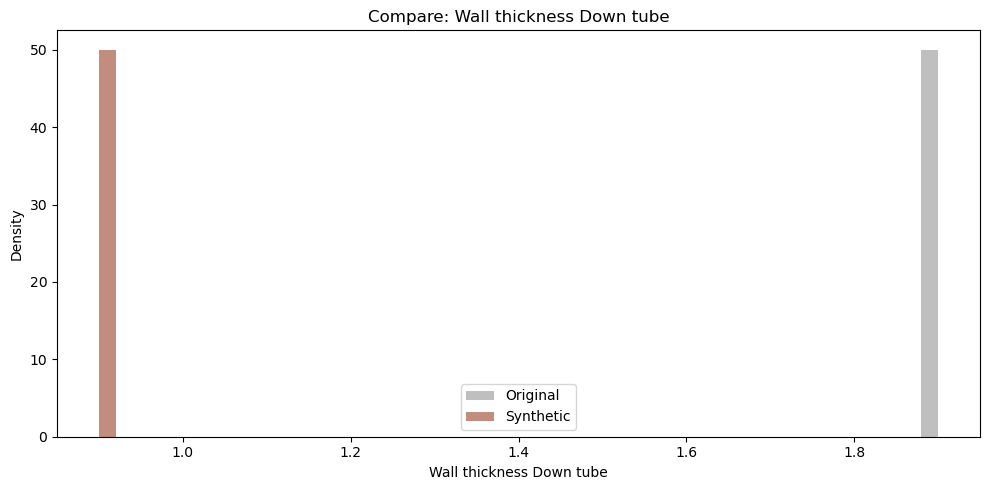

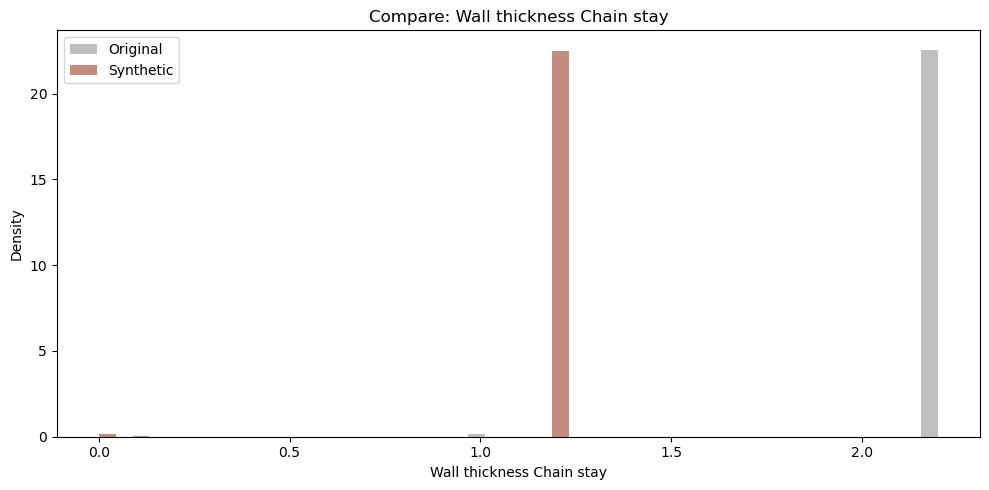

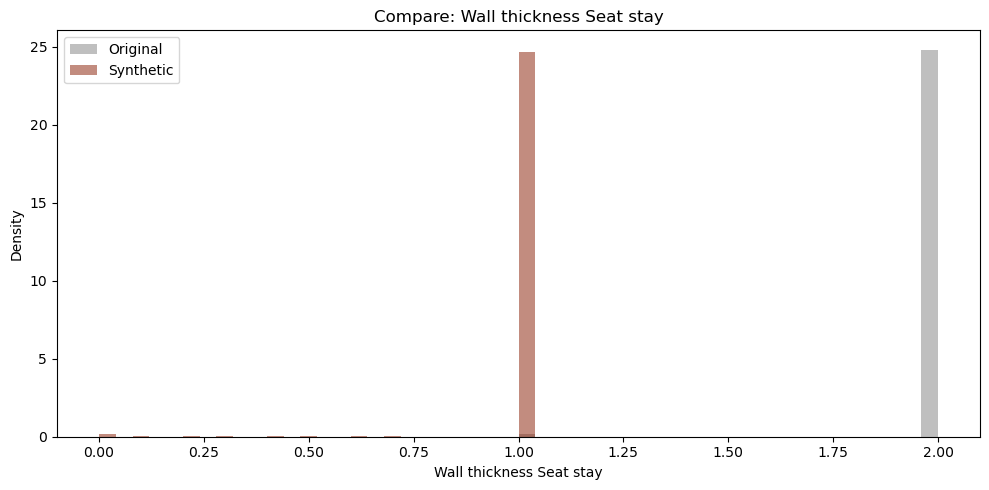

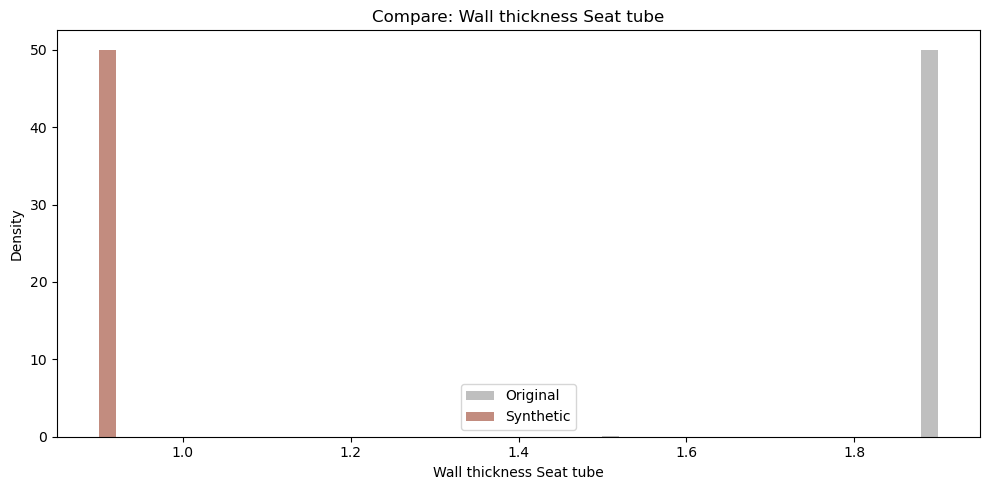

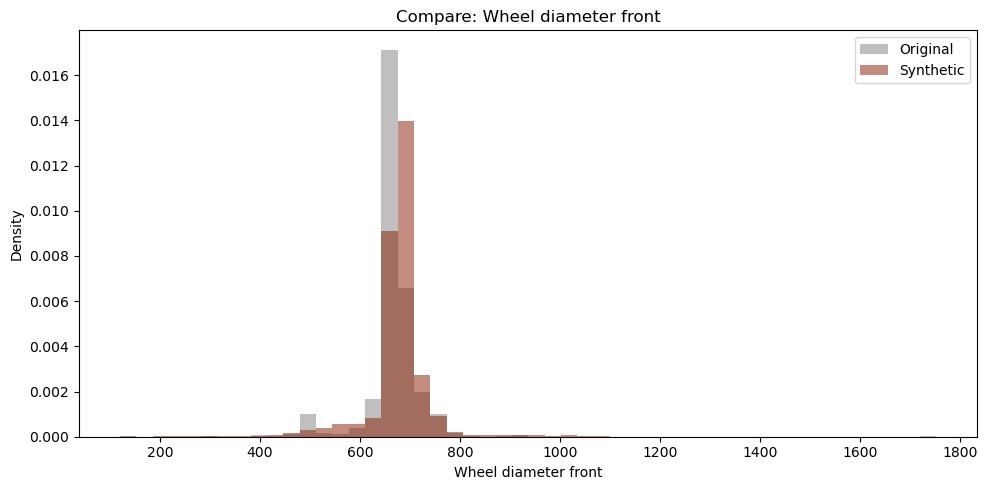

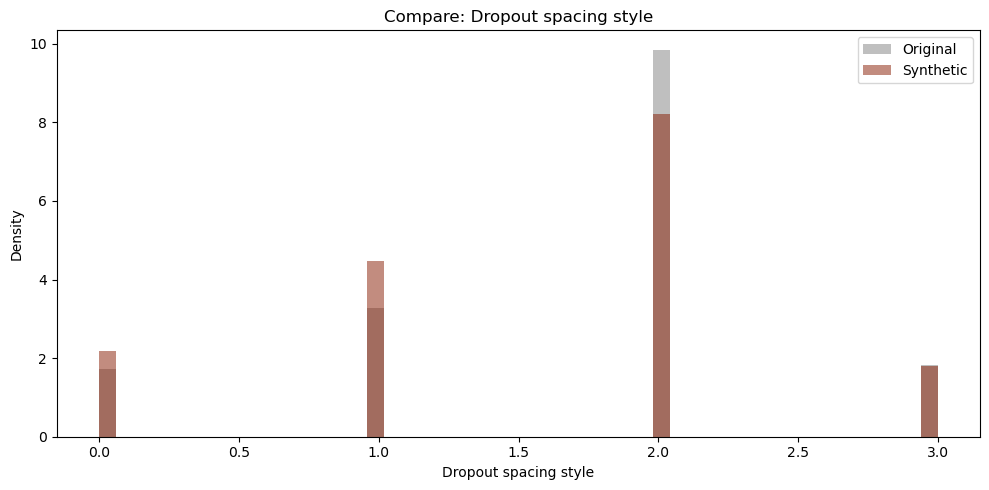

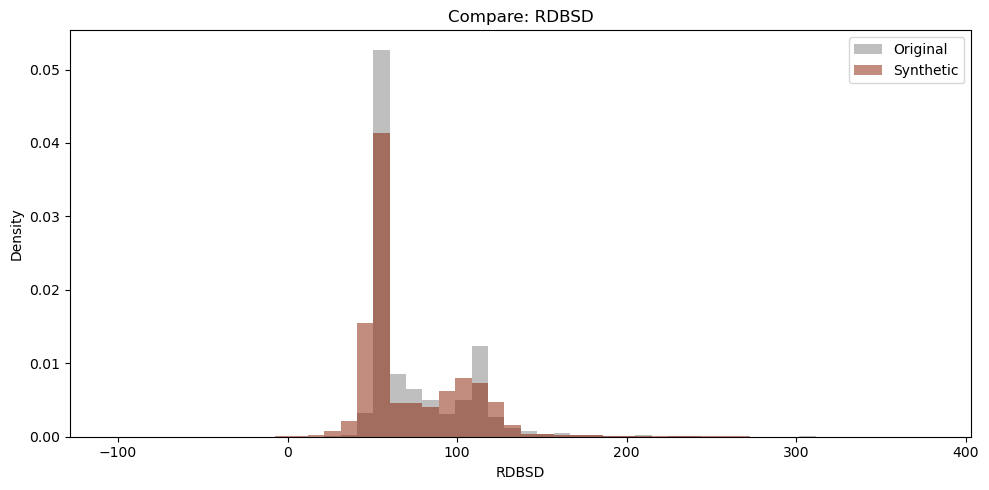

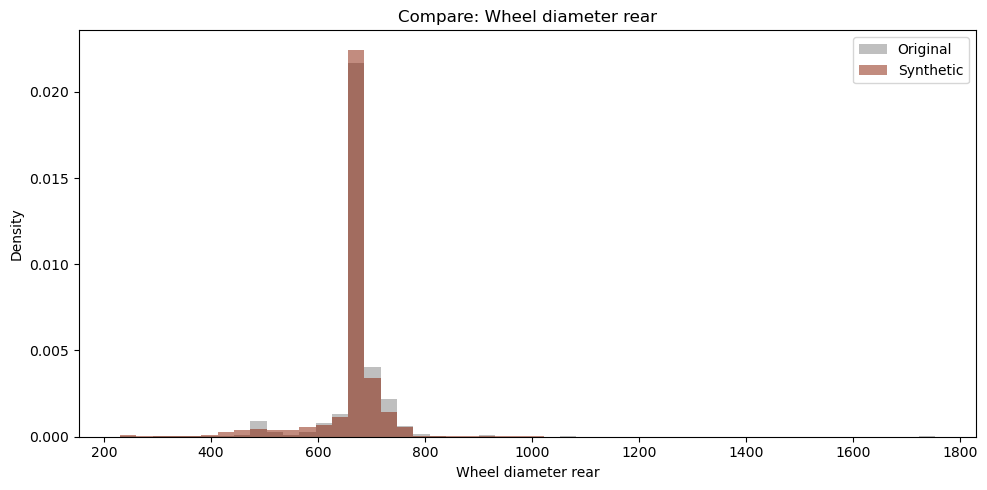

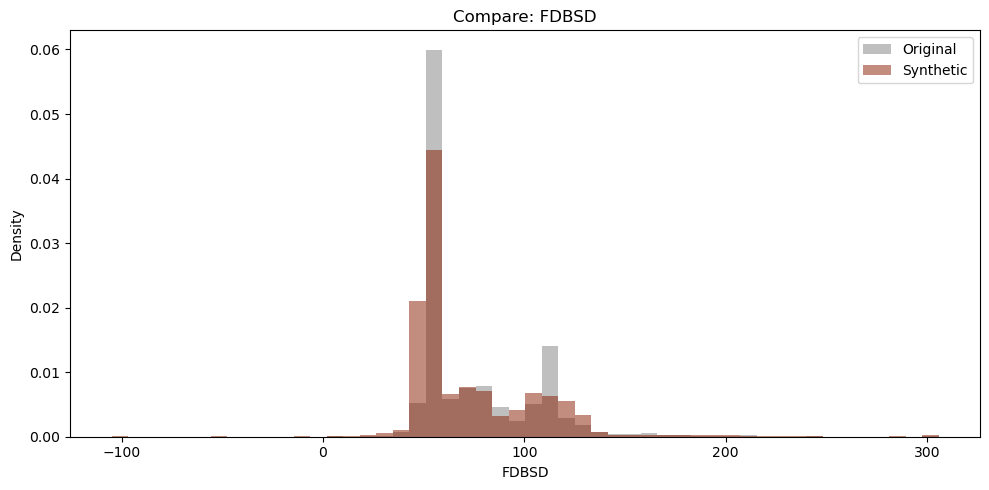

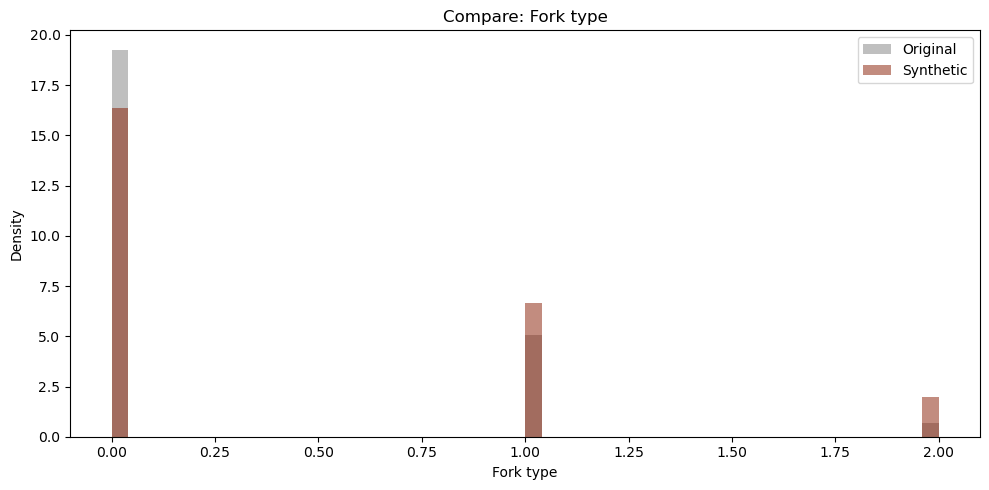

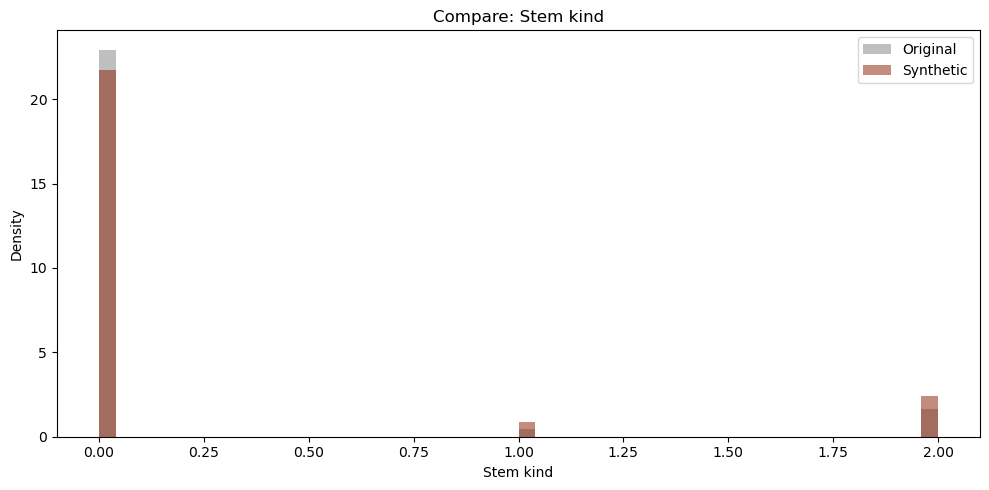

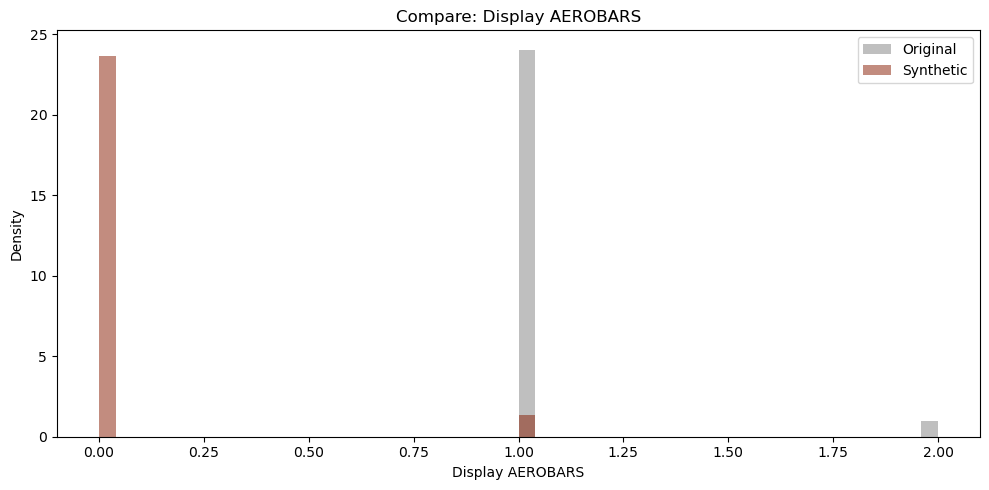

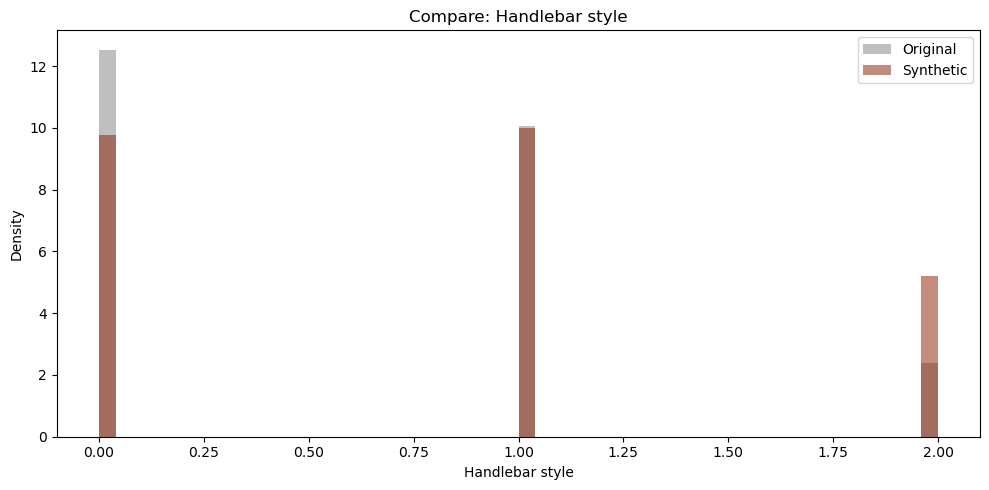

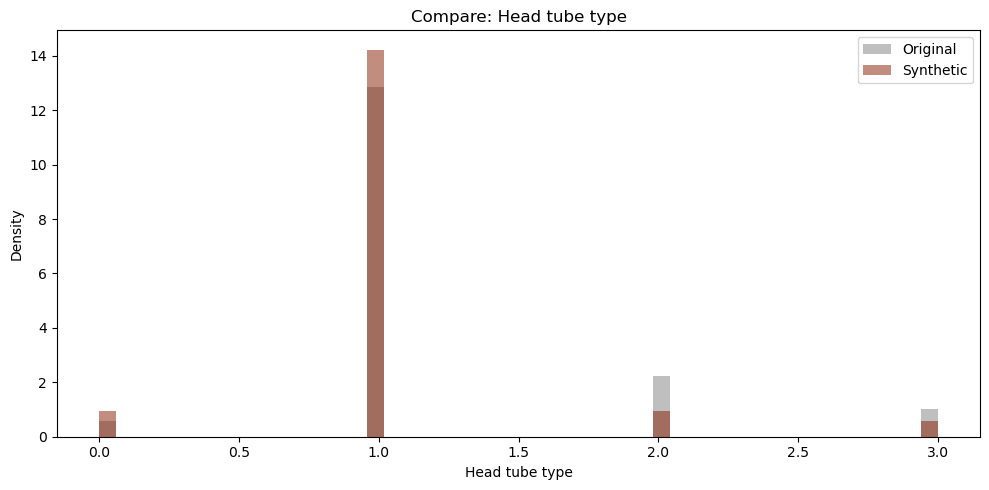

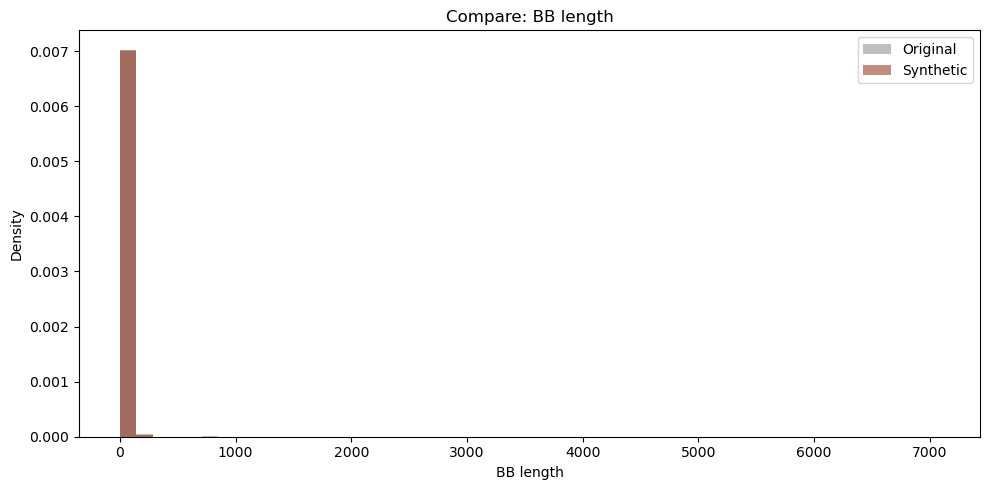

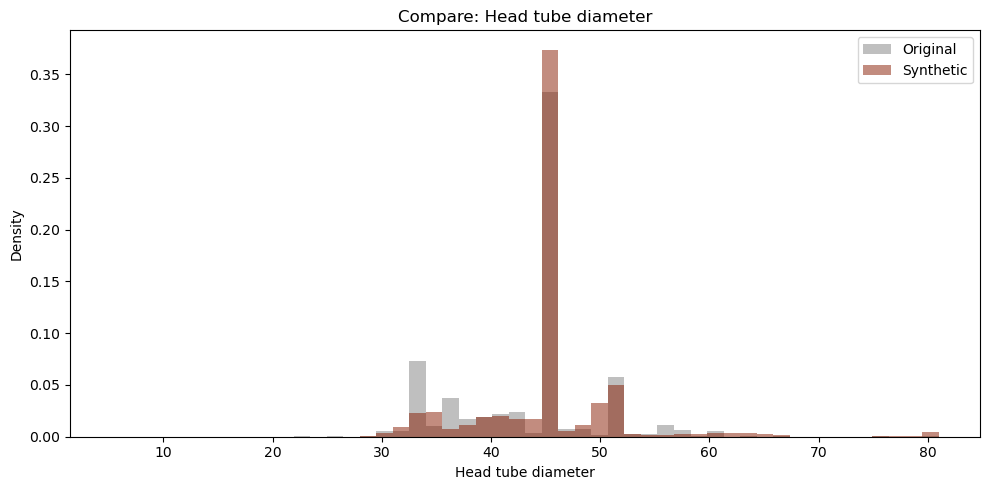

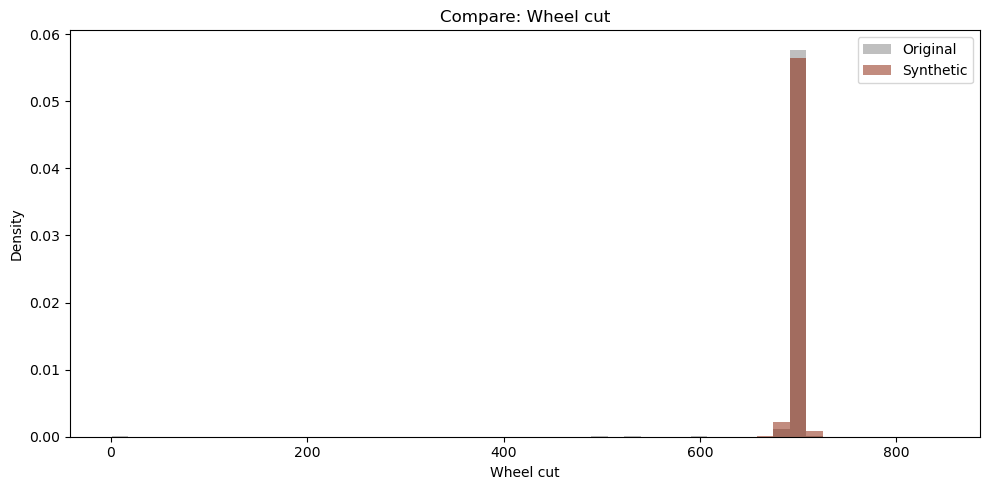

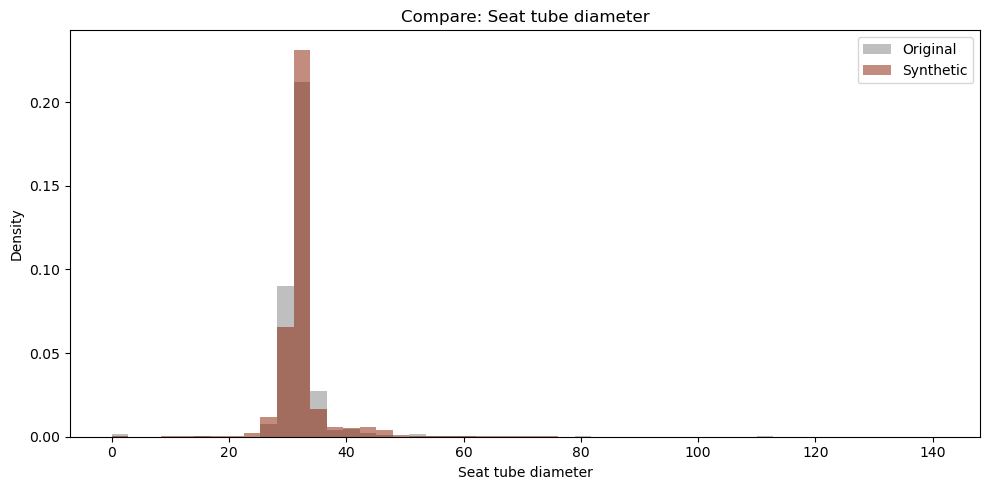

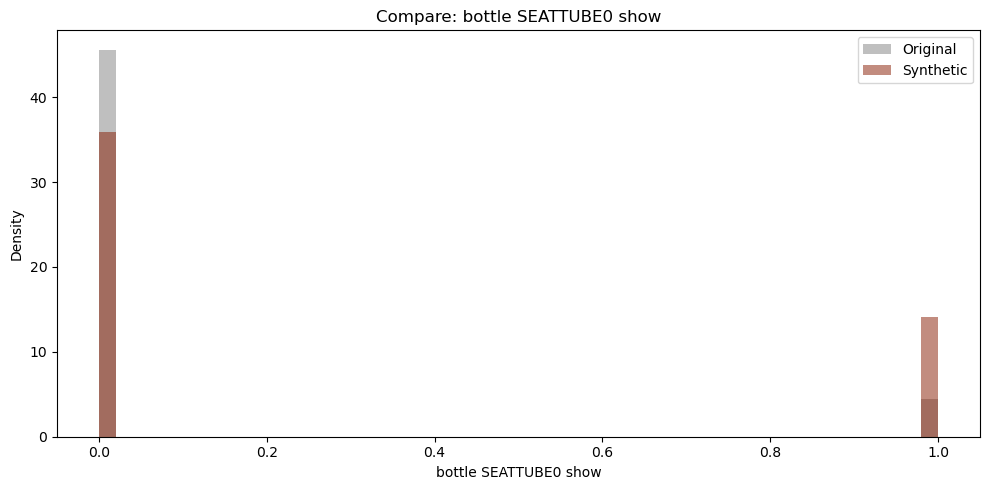

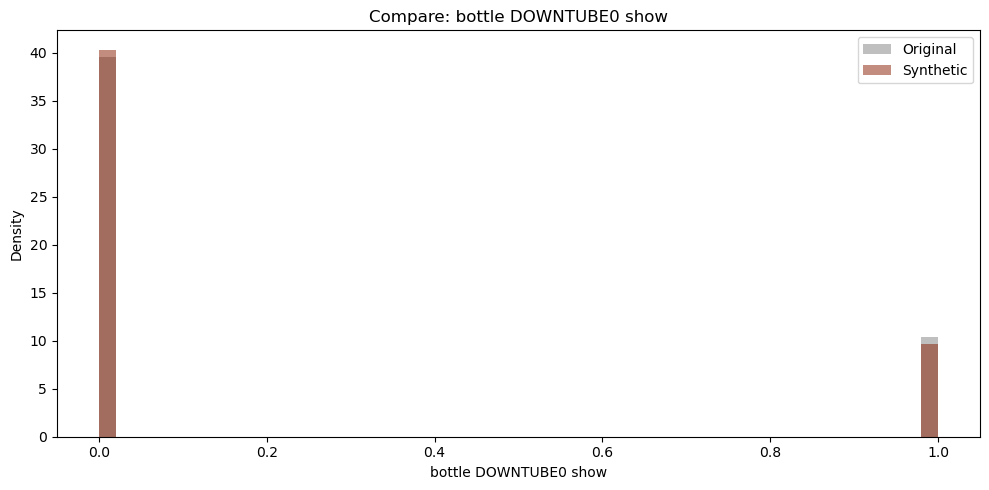

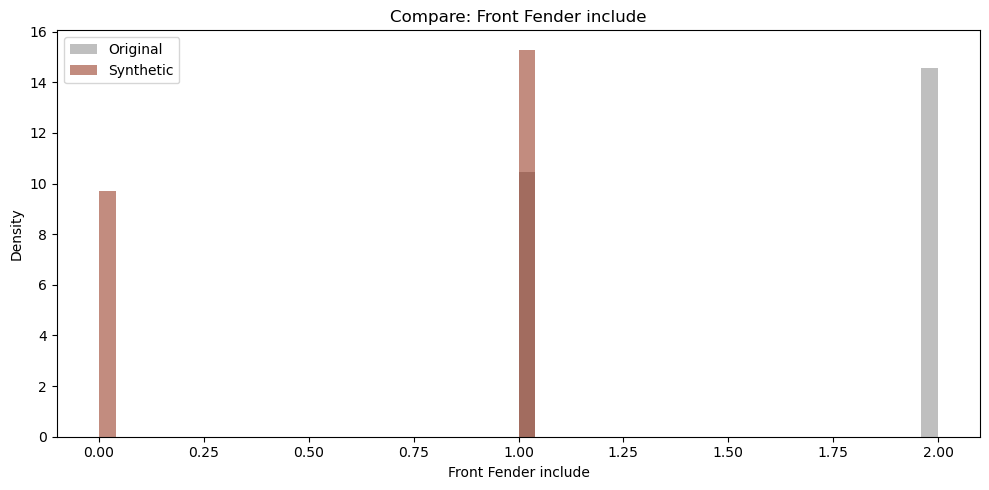

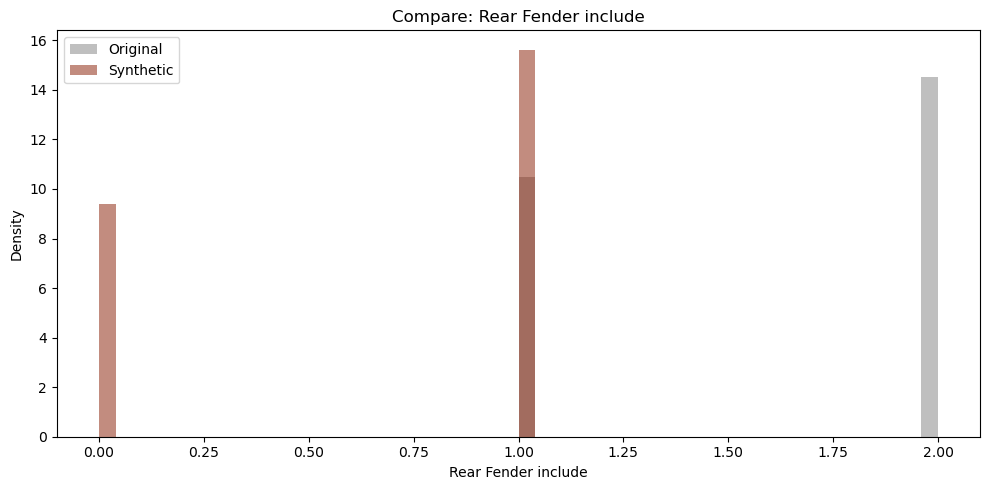

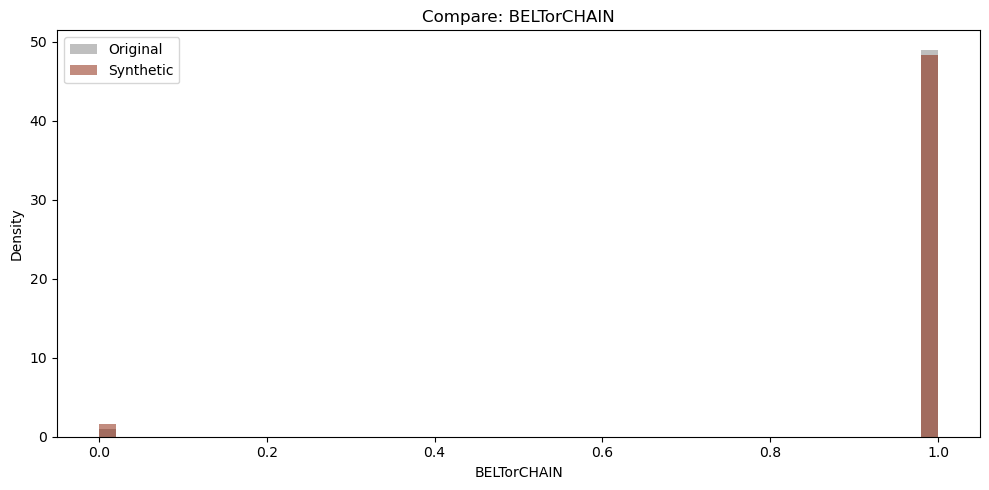

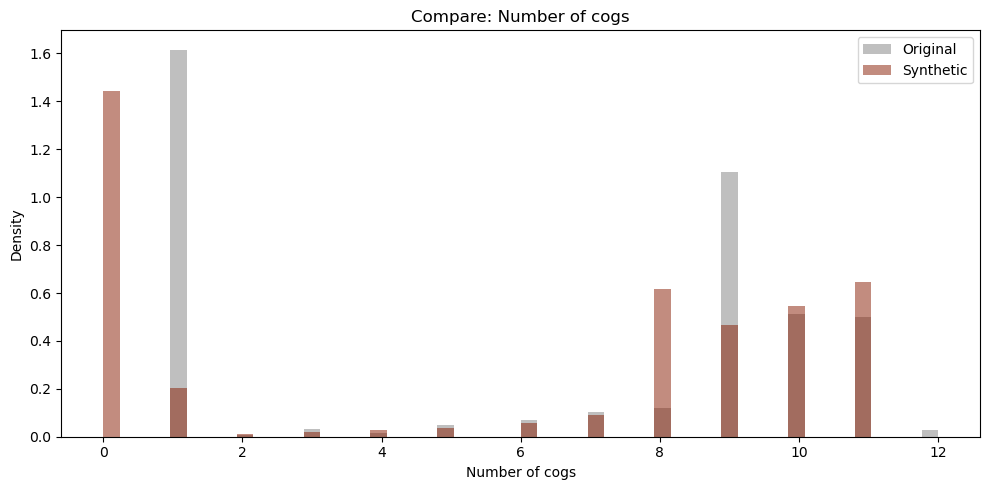

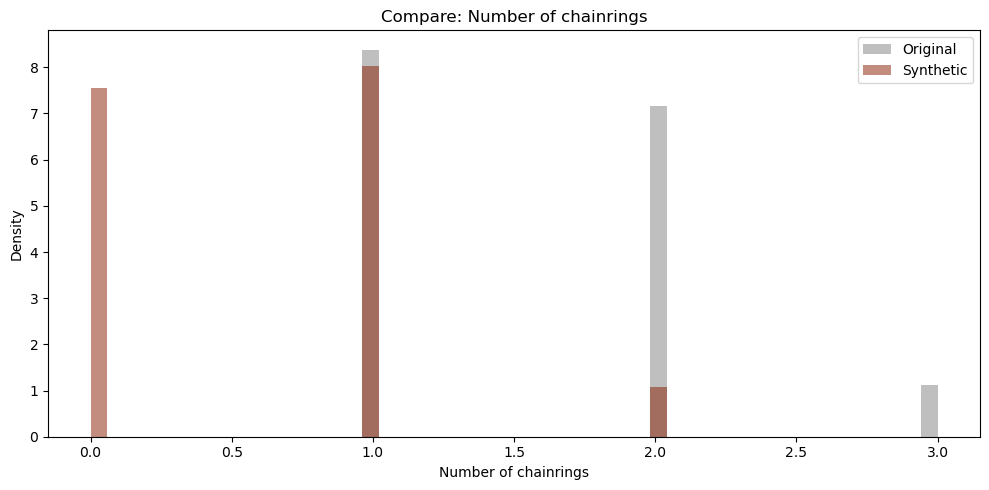

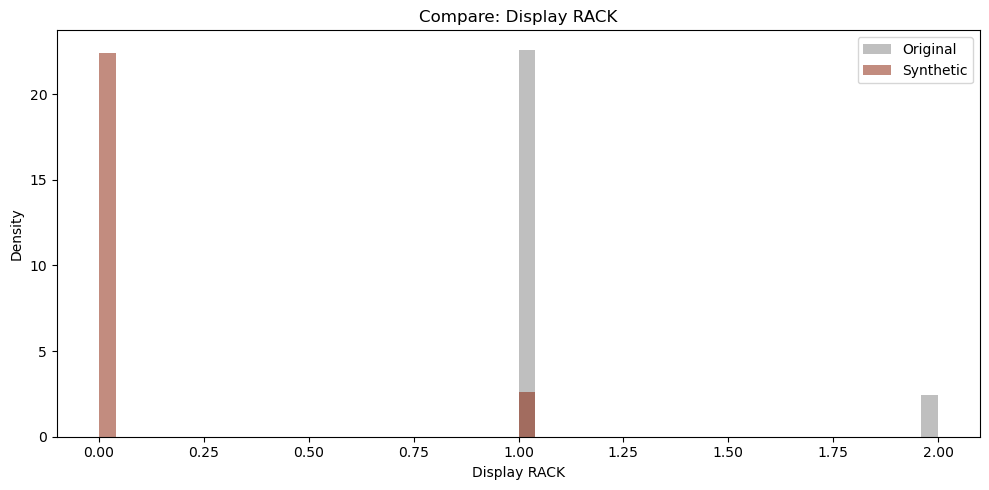

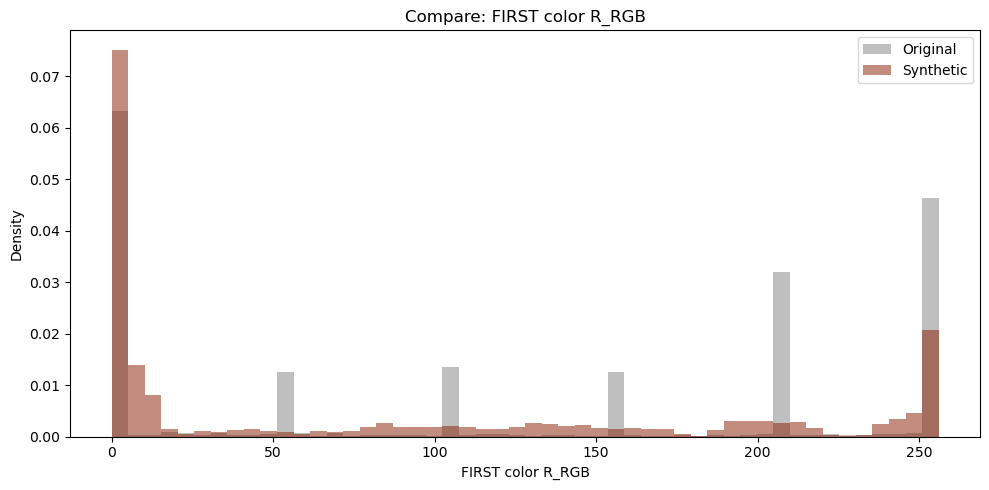

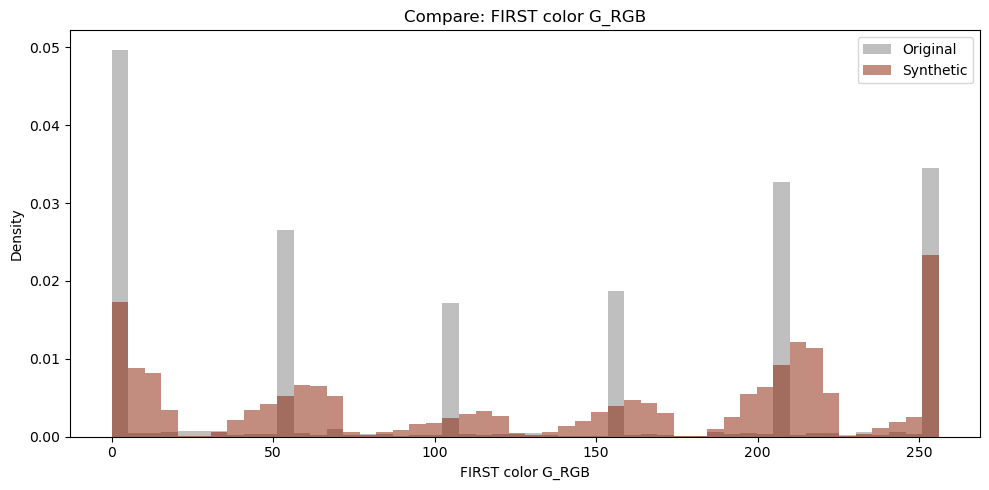

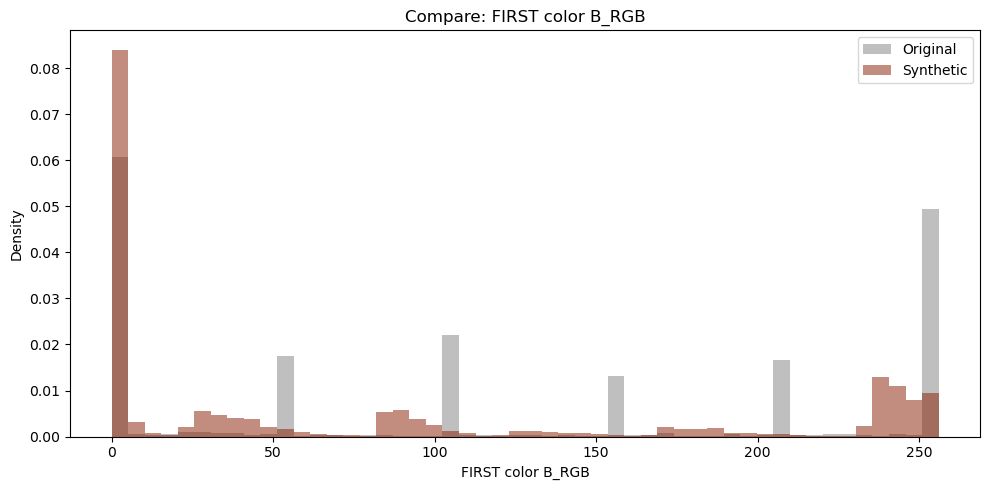

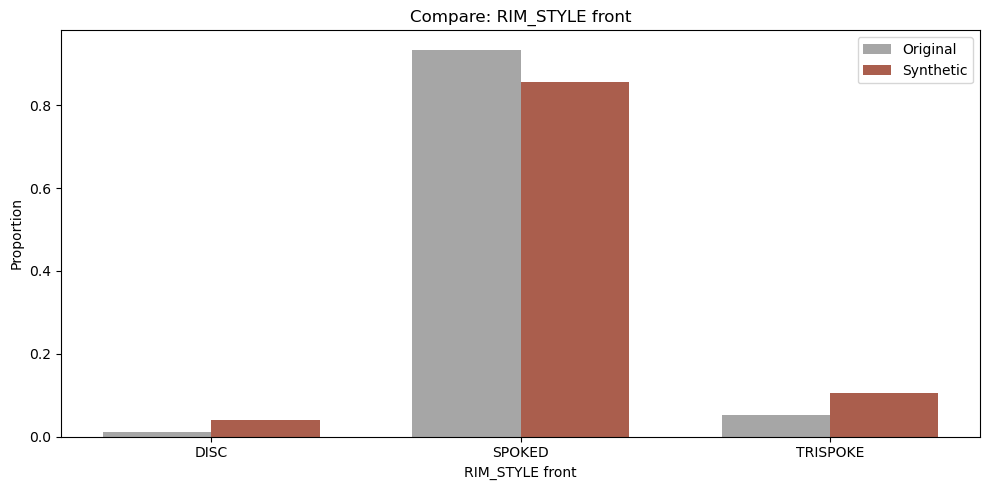

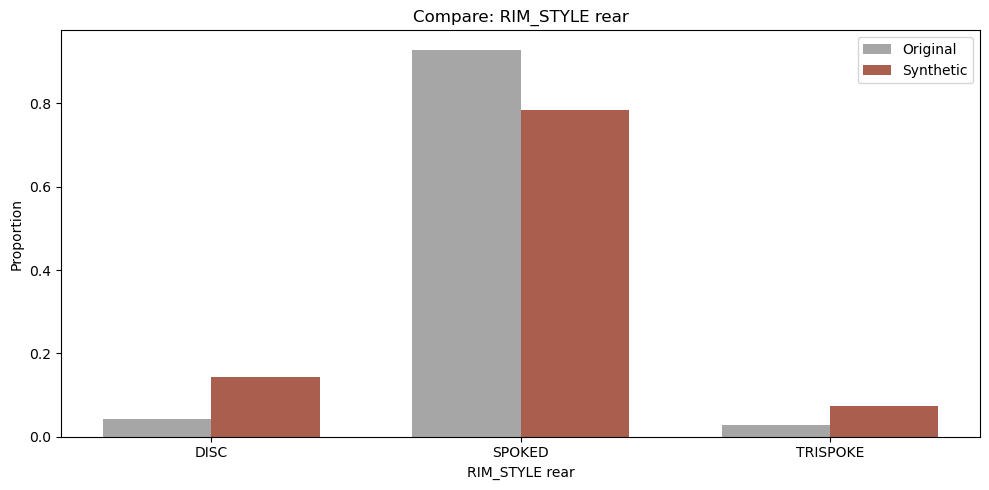

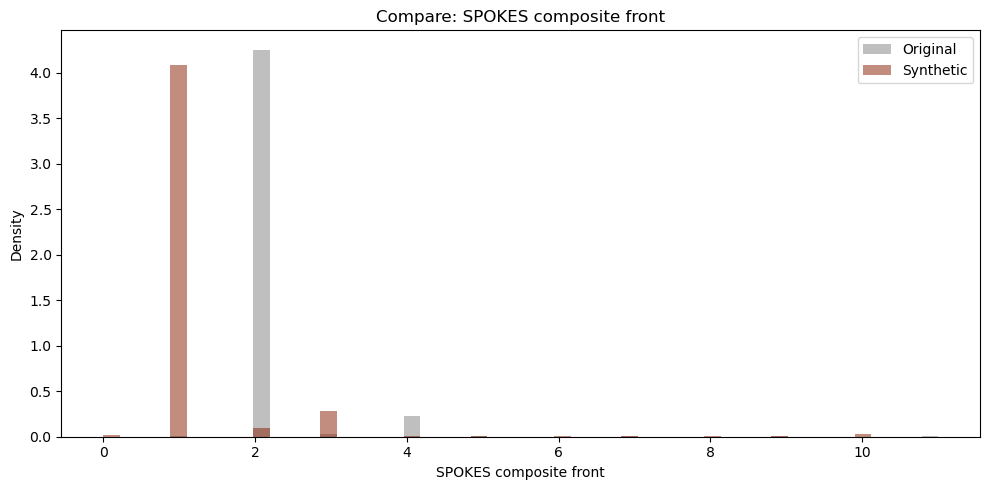

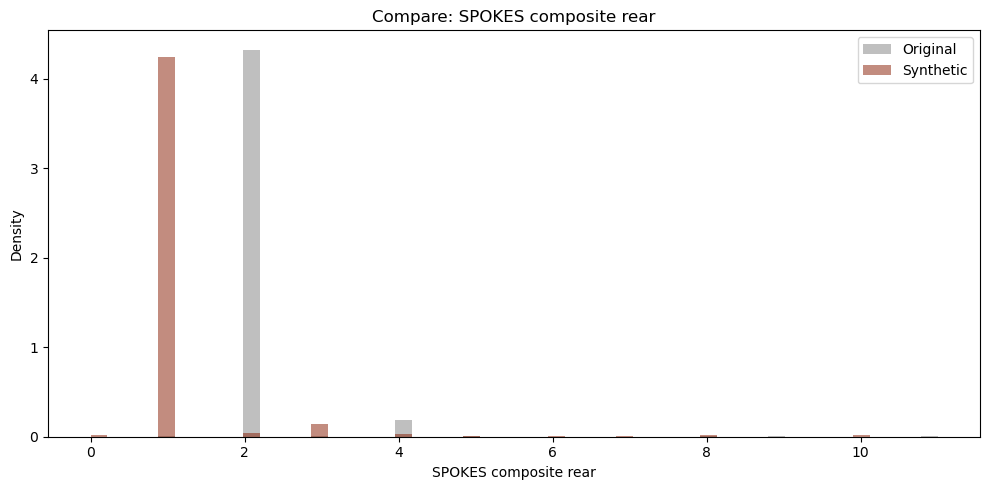

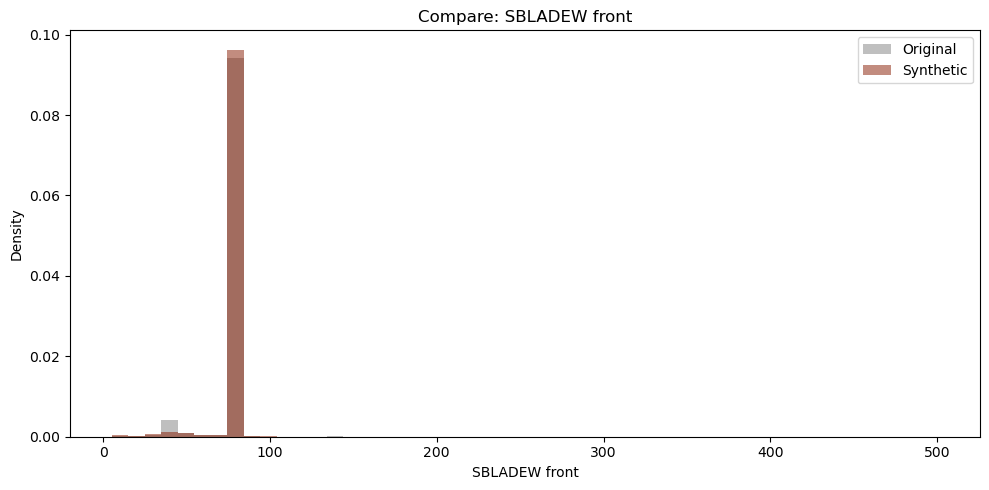

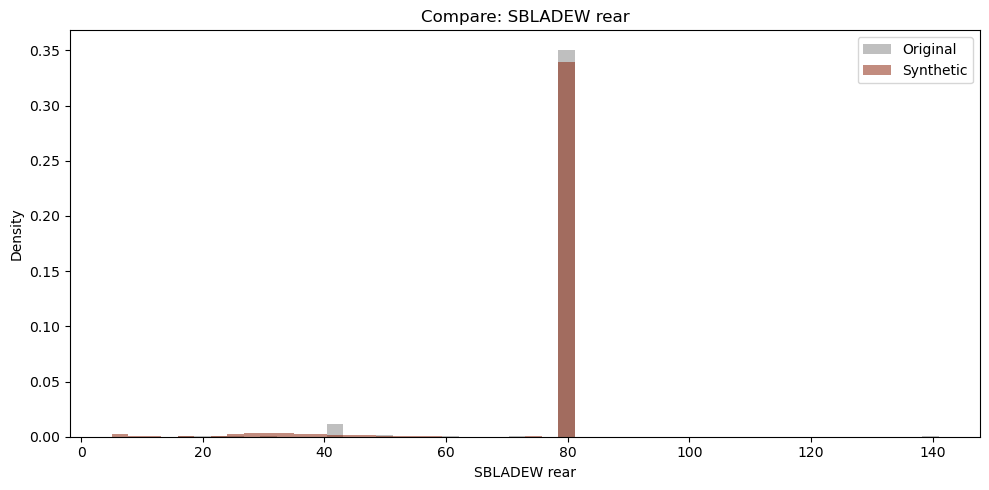

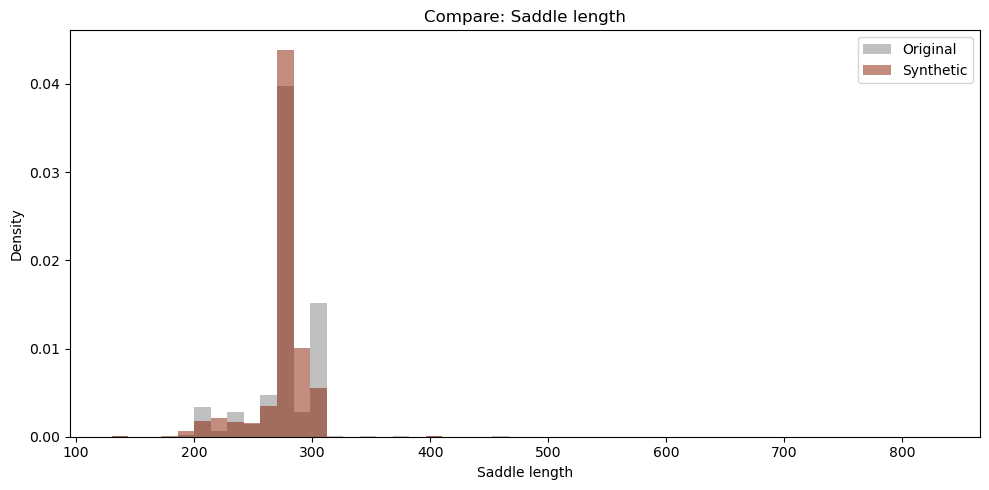

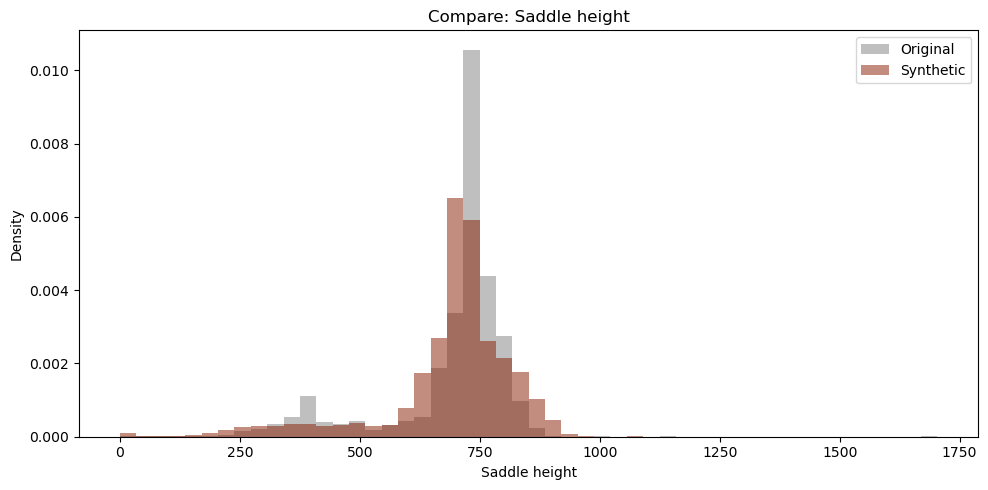

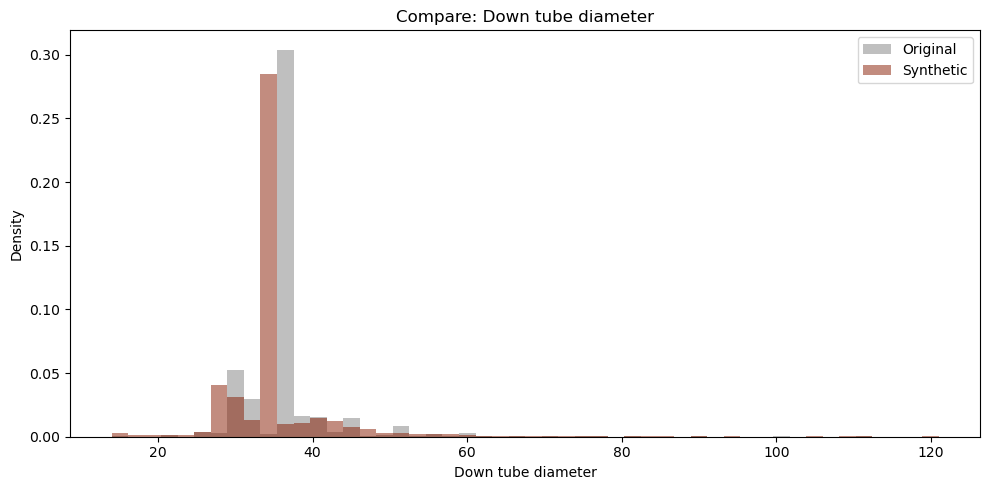

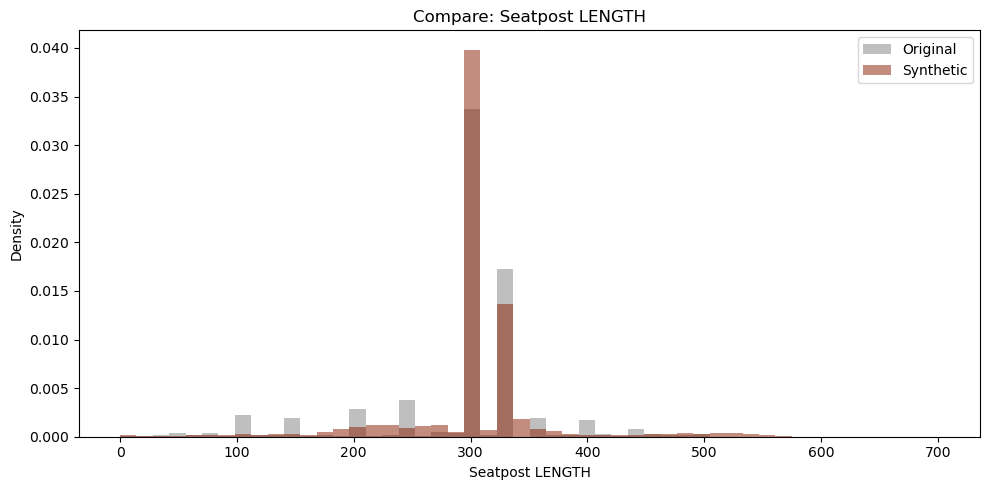

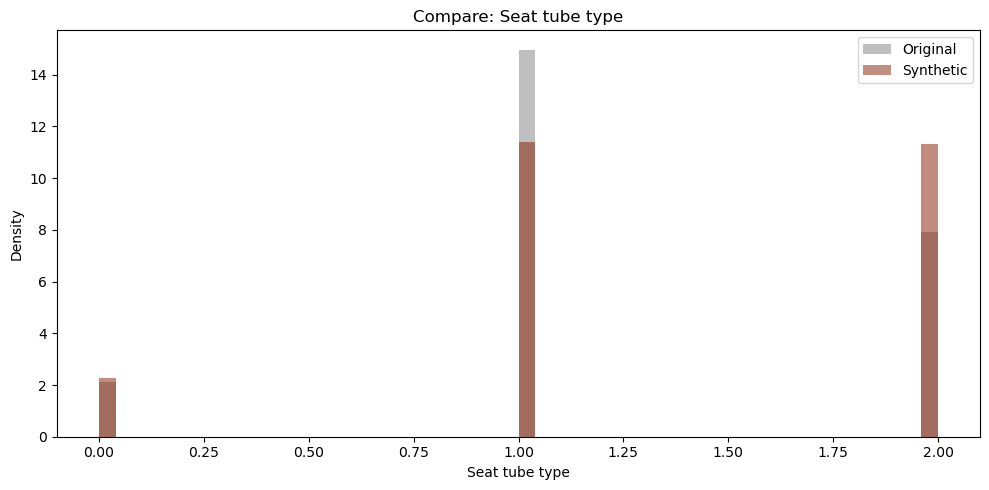

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_distributions(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    numeric_bins: int = 50,
    figsize: tuple = (10, 5)
):
    """
    For each column in real_df / synth_df:
      - Numeric: overlaid, fixed‐width histograms
      - Categorical/boolean: side‐by‐side bar plots with equal bar width
    """
    orig_color = 'gray'
    synth_color = '#871a01'
    for col in real_df.columns:
        plt.figure(figsize=figsize)
        real = real_df[col]
        synth = synth_df[col]

        # --- Numeric / ordinal columns ---
        if pd.api.types.is_numeric_dtype(real):
            # convert to numpy arrays
            r = real.dropna().to_numpy()
            s = synth.dropna().to_numpy()

            # common min/max & bins
            lo, hi = np.min([r.min(), s.min()]), np.max([r.max(), s.max()])
            bins = np.linspace(lo, hi, numeric_bins + 1)

            plt.hist(r, bins=bins, density=True, alpha=0.5, label='Original', color = orig_color)
            plt.hist(s, bins=bins, density=True, alpha=0.5, label='Synthetic', color = synth_color)
            plt.xlabel(col)
            plt.ylabel('Density')

        # --- Categorical or boolean columns ---
        else:
            # get normalized counts
            real_counts  = real.value_counts(normalize=True)
            synth_counts = synth.value_counts(normalize=True)

            # union of all categories / levels
            levels = sorted(set(real_counts.index) | set(synth_counts.index))

            # proportions in that order
            real_props  = [real_counts .get(l, 0) for l in levels]
            synth_props = [synth_counts.get(l, 0) for l in levels]

            # integer x positions & fixed bar width
            x = np.arange(len(levels))
            width = 0.35

            plt.bar(x - width/2, real_props,  width, label='Original', color=orig_color, alpha=0.7)
            plt.bar(x + width/2, synth_props, width, label='Synthetic', color=synth_color, alpha=0.7)

            # label ticks with the actual level names
            plt.xticks(x, [str(l) for l in levels])
            plt.xlabel(col)
            plt.ylabel('Proportion')

        plt.title(f'Compare: {col}')
        plt.legend()
        plt.tight_layout()
        plt.show()

compare_distributions(data, synthetic_collapsed, numeric_bins=50, figsize=(10, 5))

In [18]:
from biked_commons.transformation.one_hot_encoding import encode_to_continuous
samples_oh = encode_to_continuous(synthetic_collapsed)

In [19]:
samples_oh

,CS textfield,BB textfield,Stack,Head angle,Head tube length textfield,Seat stay junction0,Seat tube length,Seat angle,DT Length,FORK0R,...,Handlebar style OHCLASS: 2,Stem kind OHCLASS: 0,Stem kind OHCLASS: 1,Stem kind OHCLASS: 2,Fork type OHCLASS: 0,Fork type OHCLASS: 1,Fork type OHCLASS: 2,Seat tube type OHCLASS: 0,Seat tube type OHCLASS: 1,Seat tube type OHCLASS: 2
0,387.86868,67.139141,702.427113,76.772020,118.498181,40.76,605.07,73.589453,614.949524,44.11,...,True,True,False,False,True,False,False,True,False,False
1,387.44205,13.988073,462.541448,73.584112,154.757659,-5.33,363.48,65.097728,0.000000,44.77,...,False,True,False,False,True,False,False,False,True,False
2,352.19446,74.881103,591.839087,79.160227,148.170990,46.36,612.36,77.064157,678.659230,44.76,...,False,True,False,False,True,False,False,True,False,False
3,395.17996,43.859632,573.518707,72.943038,236.849988,182.44,400.22,80.797103,655.007527,44.11,...,True,True,False,False,True,False,False,False,True,False
4,418.11679,73.365800,612.756228,71.864194,219.707919,44.67,465.64,74.180075,668.054997,30.93,...,False,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,332.93582,3.868261,611.556747,71.512249,164.304941,-11.74,502.56,73.374472,638.812929,45.15,...,False,True,False,False,False,True,False,False,True,False
9996,339.26032,72.974796,633.806446,79.027713,132.674772,48.69,622.86,81.390039,682.304378,79.47,...,False,True,False,False,True,False,False,False,True,False
9997,393.33608,72.858908,603.435489,76.301934,235.291591,41.66,516.07,74.807785,623.411005,58.32,...,False,True,False,False,True,False,False,False,False,True
9998,395.95615,71.743670,618.715411,73.285898,239.132685,43.64,510.33,75.286721,630.409084,45.74,...,True,True,False,False,True,False,False,False,True,False


In [20]:
from biked_commons.api import rendering
renderer = rendering.RenderingEngine(number_rendering_servers = 1, server_init_timeout_seconds=120)



In [24]:
og = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)

In [26]:
# find diff between columns of og and samples_oh

og_columns = set(og.columns)
samples_oh_columns = set(samples_oh.columns)
diff = og_columns.difference(samples_oh_columns)
diff

{'BELTorCHAIN OHCLASS: 0',
 'BELTorCHAIN OHCLASS: 1',
 'bottle DOWNTUBE0 show OHCLASS: False',
 'bottle DOWNTUBE0 show OHCLASS: True',
 'bottle SEATTUBE0 show OHCLASS: False',
 'bottle SEATTUBE0 show OHCLASS: True'}

In [21]:
data1 = samples_oh.iloc[0]
res = renderer.render_clip(data1)
svg = res.image_bytes
from IPython.display import SVG, display
display(SVG(svg))

/home/mileva/mambaforge/envs/torch/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


IndexError: list index out of range